In [4]:
import pandas as pd
import glob

folder_path = "../data/attack/compromised-scada/attack logs/**/*.csv"

distinct_values = set()

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["TargetIP"].dropna().unique())

print(distinct_values)

{'185.175.0.5', '185.175.0.4', '185.175.0.8'}


In [5]:
folder_path = "../data/attack/compromised-ied/attack logs/**/*.csv"

distinct_values = set()

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["TargetIP"].dropna().unique())

print(distinct_values)

{'185.175.0.2'}


In [ ]:
folder_path = "../data/attack/external/external-attacker/attacker logs/**/*.csv"

distinct_values = set() 

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["Attack"].dropna().unique())

print(distinct_values)

{'Replay', 'Recon. Range: 65535', 'Payload injection - Complete', 'Stacked Modbus Frames - Complete', 'Recon. Range: 9', 'Replay - Complete', 'Recon. Range: 2', 'Length manipulation - Complete', 'Brute force or specific - Complete', 'Stacked Modbus Frames', 'Payload injection', 'Query flooding. Complete', 'Recon. Range: 1', 'Recon. Range: 20', 'Length manipulation', 'Recon. Range: 4', 'Brute force or specific coil. Address: 0', 'Query Flooding', 'Recon. Complete', 'Brute force or specific coil. Address: 13', 'Recon. Range: 5'}


In [2]:
import ipaddress
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

READ_FUNCTION_CODES = {1, 2, 3, 4}
WRITE_FUNCTION_CODES = {5, 6, 15, 16}


def _load_csv_file(input_csv):
    input_path = Path(input_csv)
    if not input_path.exists():
        raise FileNotFoundError(f"Input CSV not found: {input_path}")
    if input_path.suffix.lower() != ".csv":
        raise ValueError(f"Input file must be a CSV: {input_path}")

    combined = pd.read_csv(input_path, low_memory=False)
    combined["source_file"] = input_path.name
    return combined, input_path


def _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds=0):
    ipaddress.ip_address(ip_address)

    combined, input_path = _load_csv_file(input_csv)

    required_cols = {"ip.src", "ip.dst", "frame.time_epoch"}
    missing = required_cols - set(combined.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    frame_epoch = pd.to_numeric(combined["frame.time_epoch"], errors="coerce")
    combined = combined.loc[frame_epoch.notna()].copy()
    combined["aligned_epoch"] = frame_epoch[frame_epoch.notna()] + float(time_offset_seconds)
    combined["aligned_ts"] = pd.to_datetime(combined["aligned_epoch"], unit="s", errors="coerce")
    combined = combined.dropna(subset=["aligned_ts"]).copy()

    target_ts = pd.to_datetime(timestamp, errors="raise")
    window_start = target_ts - pd.Timedelta(seconds=time_range_seconds)
    window_end = target_ts + pd.Timedelta(seconds=time_range_seconds)
    target_second = target_ts.floor("s")

    src = combined["ip.src"].fillna("").astype(str)
    dst = combined["ip.dst"].fillna("").astype(str)
    ip_df = combined[(src == ip_address) | (dst == ip_address)].copy()
    ip_df = ip_df.sort_values("aligned_ts")

    window_df = ip_df[(ip_df["aligned_ts"] >= window_start) & (ip_df["aligned_ts"] <= window_end)].copy()
    window_df = window_df.sort_values("aligned_ts")
    if not window_df.empty:
        window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    plot_bins = pd.date_range(
        start=target_second - pd.Timedelta(seconds=time_range_seconds),
        end=target_second + pd.Timedelta(seconds=time_range_seconds),
        freq="s",
    )

    return {
        "combined": combined,
        "input_path": input_path,
        "ip_df": ip_df,
        "window_df": window_df,
        "target_ts": target_ts,
        "window_start": window_start,
        "window_end": window_end,
        "target_second": target_second,
        "plot_bins": plot_bins,
    }


def _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, metric_name):
    window_df = context["window_df"]
    ip_df = context["ip_df"]
    target_ts = context["target_ts"]
    window_start = context["window_start"]
    window_end = context["window_end"]
    input_path = context["input_path"]

    print(f"Attack name: {attack_name}")
    print(f"Input CSV: {input_path}")
    print(f"IP: {ip_address}")
    print(f"Input rows: {len(context['combined'])}")
    print(f"Rows for IP {ip_address}: {len(ip_df)}")
    print(f"Window: {window_start} -> {window_end}")
    print(f"Rows in +/-{time_range_seconds} second window: {len(window_df)}")
    print(f"Time offset applied: {time_offset_seconds} seconds")
    print(f"Metric: {metric_name}")
    print(f"Target timestamp: {target_ts}")

    if not window_df.empty:
        print(f"Window start in data: {window_df['aligned_ts'].min()}")
        print(f"Window end in data:   {window_df['aligned_ts'].max()}")
    else:
        print("No rows in requested window.")
        print(f"IP time range in this data: {ip_df['aligned_ts'].min()} -> {ip_df['aligned_ts'].max()}")

    if not ip_df.empty:
        abs_delta_s = (ip_df["aligned_ts"] - target_ts).abs().dt.total_seconds()
        nearest_idx = abs_delta_s.idxmin()
        nearest_row = ip_df.loc[nearest_idx]
        print("Nearest packet for this IP:")
        nearest_cols = [
            c
            for c in [
                "aligned_ts",
                "frame.time_epoch",
                "ip.src",
                "ip.dst",
                "frame.len",
                "modbus.func_code",
                "modbus.exception_code",
            ]
            if c in ip_df.columns
        ]
        print(nearest_row[nearest_cols].to_string())
        print(f"Absolute time delta (s): {abs_delta_s.loc[nearest_idx]:.6f}")


def _build_directional_series(window_df, plot_bins, target_ip, value_column=None, filter_mask=None):
    if window_df.empty:
        return (
            pd.Series(0, index=plot_bins, dtype=float),
            pd.Series(0, index=plot_bins, dtype=float),
        )

    tx_df = window_df[window_df["ip.src"].astype(str) == target_ip].copy()
    rx_df = window_df[window_df["ip.dst"].astype(str) == target_ip].copy()

    if filter_mask is not None:
        tx_df = tx_df[filter_mask(tx_df)]
        rx_df = rx_df[filter_mask(rx_df)]

    if value_column is None:
        tx_series = tx_df.groupby("second_bin").size().reindex(plot_bins, fill_value=0).astype(float)
        rx_series = rx_df.groupby("second_bin").size().reindex(plot_bins, fill_value=0).astype(float)
        return tx_series, rx_series

    tx_vals = pd.to_numeric(tx_df[value_column], errors="coerce").fillna(0)
    rx_vals = pd.to_numeric(rx_df[value_column], errors="coerce").fillna(0)
    tx_df = tx_df.assign(_value=tx_vals)
    rx_df = rx_df.assign(_value=rx_vals)

    tx_series = tx_df.groupby("second_bin")["_value"].sum().reindex(plot_bins, fill_value=0).astype(float)
    rx_series = rx_df.groupby("second_bin")["_value"].sum().reindex(plot_bins, fill_value=0).astype(float)
    return tx_series, rx_series


def _plot_dual_ip_directional_series(
    plot_bins,
    target_second,
    attacker_ip,
    victim_ip,
    attacker_tx,
    attacker_rx,
    victim_tx,
    victim_rx,
    title,
    ylabel,
    attack_name,
    time_range_seconds,
):
    rel_x = (plot_bins - target_second).total_seconds().astype(int)
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

    axes[0, 0].plot(rel_x, attacker_tx.values, marker="o", label="TX")
    axes[0, 0].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[0, 0].set_title(f"Attacker TX ({attacker_ip})")
    axes[0, 0].set_ylabel(ylabel)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[1, 0].plot(rel_x, attacker_rx.values, marker="o", label="RX")
    axes[1, 0].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[1, 0].set_title(f"Attacker RX ({attacker_ip})")
    axes[1, 0].set_xlabel("Seconds offset from target timestamp")
    axes[1, 0].set_ylabel(ylabel)
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.25)

    axes[0, 1].plot(rel_x, victim_tx.values, marker="o", label="TX")
    axes[0, 1].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[0, 1].set_title(f"Victim TX ({victim_ip})")
    axes[0, 1].set_ylabel(ylabel)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    axes[1, 1].plot(rel_x, victim_rx.values, marker="o", label="RX")
    axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[1, 1].set_title(f"Victim RX ({victim_ip})")
    axes[1, 1].set_xlabel("Seconds offset from target timestamp")
    axes[1, 1].set_ylabel(ylabel)
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.25)

    fig.suptitle(f"{title} | {attack_name} (+/-{time_range_seconds} seconds)", y=1.02)
    plt.tight_layout()
    plt.show()


def _build_two_contexts(input_csv, attacker_ip, victim_ip, timestamp, time_range_seconds, time_offset_seconds):
    attacker_ctx = _prepare_ip_window(input_csv, attacker_ip, timestamp, time_range_seconds, time_offset_seconds)
    victim_ctx = _prepare_ip_window(input_csv, victim_ip, timestamp, time_range_seconds, time_offset_seconds)
    return attacker_ctx, victim_ctx


def plot_packet_counts_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    attacker_ctx, victim_ctx = _build_two_contexts(
        input_csv, attacker_ip, victim_ip, timestamp, time_range_seconds, time_offset_seconds
    )
    bins = attacker_ctx["plot_bins"]
    target_second = attacker_ctx["target_second"]

    attacker_tx, attacker_rx = _build_directional_series(attacker_ctx["window_df"], bins, attacker_ip)
    victim_tx, victim_rx = _build_directional_series(victim_ctx["window_df"], bins, victim_ip)

    _plot_dual_ip_directional_series(
        bins,
        target_second,
        attacker_ip,
        victim_ip,
        attacker_tx,
        attacker_rx,
        victim_tx,
        victim_rx,
        "Packet counts per second",
        "Packet count",
        attack_name,
        time_range_seconds,
    )

    if debug:
        print("===== ATTACKER DEBUG =====")
        _debug_window_summary(attacker_ctx, attacker_ip, attack_name, time_range_seconds, time_offset_seconds, "Packet counts per second")
        print(f"TX packet total: {int(attacker_tx.sum())}")
        print(f"RX packet total: {int(attacker_rx.sum())}")
        print("===== VICTIM DEBUG =====")
        _debug_window_summary(victim_ctx, victim_ip, attack_name, time_range_seconds, time_offset_seconds, "Packet counts per second")
        print(f"TX packet total: {int(victim_tx.sum())}")
        print(f"RX packet total: {int(victim_rx.sum())}")

    return {"attacker": attacker_ctx["window_df"], "victim": victim_ctx["window_df"]}


def plot_payload_bytes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    attacker_ctx, victim_ctx = _build_two_contexts(
        input_csv, attacker_ip, victim_ip, timestamp, time_range_seconds, time_offset_seconds
    )
    bins = attacker_ctx["plot_bins"]
    target_second = attacker_ctx["target_second"]

    if "frame.len" not in attacker_ctx["window_df"].columns or "frame.len" not in victim_ctx["window_df"].columns:
        raise ValueError("Missing required column for byte-length plot: frame.len")

    attacker_tx, attacker_rx = _build_directional_series(attacker_ctx["window_df"], bins, attacker_ip, value_column="frame.len")
    victim_tx, victim_rx = _build_directional_series(victim_ctx["window_df"], bins, victim_ip, value_column="frame.len")

    _plot_dual_ip_directional_series(
        bins,
        target_second,
        attacker_ip,
        victim_ip,
        attacker_tx,
        attacker_rx,
        victim_tx,
        victim_rx,
        "Payload bytes per second",
        "Bytes",
        attack_name,
        time_range_seconds,
    )

    if debug:
        print("===== ATTACKER DEBUG =====")
        _debug_window_summary(attacker_ctx, attacker_ip, attack_name, time_range_seconds, time_offset_seconds, "Payload bytes per second")
        print(f"TX byte total: {int(attacker_tx.sum())}")
        print(f"RX byte total: {int(attacker_rx.sum())}")
        print("===== VICTIM DEBUG =====")
        _debug_window_summary(victim_ctx, victim_ip, attack_name, time_range_seconds, time_offset_seconds, "Payload bytes per second")
        print(f"TX byte total: {int(victim_tx.sum())}")
        print(f"RX byte total: {int(victim_rx.sum())}")

    return {"attacker": attacker_ctx["window_df"], "victim": victim_ctx["window_df"]}


def plot_write_function_codes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    attacker_ctx, victim_ctx = _build_two_contexts(
        input_csv, attacker_ip, victim_ip, timestamp, time_range_seconds, time_offset_seconds
    )
    bins = attacker_ctx["plot_bins"]
    target_second = attacker_ctx["target_second"]

    def _is_write(frame):
        codes = pd.to_numeric(frame["modbus.func_code"], errors="coerce")
        return codes.isin(WRITE_FUNCTION_CODES)

    attacker_tx, attacker_rx = _build_directional_series(attacker_ctx["window_df"], bins, attacker_ip, filter_mask=_is_write)
    victim_tx, victim_rx = _build_directional_series(victim_ctx["window_df"], bins, victim_ip, filter_mask=_is_write)

    _plot_dual_ip_directional_series(
        bins,
        target_second,
        attacker_ip,
        victim_ip,
        attacker_tx,
        attacker_rx,
        victim_tx,
        victim_rx,
        "Write function codes per second",
        "Count",
        attack_name,
        time_range_seconds,
    )

    if debug:
        print("===== ATTACKER DEBUG =====")
        _debug_window_summary(attacker_ctx, attacker_ip, attack_name, time_range_seconds, time_offset_seconds, "Write function codes per second")
        print(f"TX write-code total: {int(attacker_tx.sum())}")
        print(f"RX write-code total: {int(attacker_rx.sum())}")
        print("===== VICTIM DEBUG =====")
        _debug_window_summary(victim_ctx, victim_ip, attack_name, time_range_seconds, time_offset_seconds, "Write function codes per second")
        print(f"TX write-code total: {int(victim_tx.sum())}")
        print(f"RX write-code total: {int(victim_rx.sum())}")

    return {"attacker": attacker_ctx["window_df"], "victim": victim_ctx["window_df"]}


def plot_read_function_codes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    attacker_ctx, victim_ctx = _build_two_contexts(
        input_csv, attacker_ip, victim_ip, timestamp, time_range_seconds, time_offset_seconds
    )
    bins = attacker_ctx["plot_bins"]
    target_second = attacker_ctx["target_second"]

    def _is_read(frame):
        codes = pd.to_numeric(frame["modbus.func_code"], errors="coerce")
        return codes.isin(READ_FUNCTION_CODES)

    attacker_tx, attacker_rx = _build_directional_series(attacker_ctx["window_df"], bins, attacker_ip, filter_mask=_is_read)
    victim_tx, victim_rx = _build_directional_series(victim_ctx["window_df"], bins, victim_ip, filter_mask=_is_read)

    _plot_dual_ip_directional_series(
        bins,
        target_second,
        attacker_ip,
        victim_ip,
        attacker_tx,
        attacker_rx,
        victim_tx,
        victim_rx,
        "Read function codes per second",
        "Count",
        attack_name,
        time_range_seconds,
    )

    if debug:
        print("===== ATTACKER DEBUG =====")
        _debug_window_summary(attacker_ctx, attacker_ip, attack_name, time_range_seconds, time_offset_seconds, "Read function codes per second")
        print(f"TX read-code total: {int(attacker_tx.sum())}")
        print(f"RX read-code total: {int(attacker_rx.sum())}")
        print("===== VICTIM DEBUG =====")
        _debug_window_summary(victim_ctx, victim_ip, attack_name, time_range_seconds, time_offset_seconds, "Read function codes per second")
        print(f"TX read-code total: {int(victim_tx.sum())}")
        print(f"RX read-code total: {int(victim_rx.sum())}")

    return {"attacker": attacker_ctx["window_df"], "victim": victim_ctx["window_df"]}


def plot_exception_codes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    attacker_ctx, victim_ctx = _build_two_contexts(
        input_csv, attacker_ip, victim_ip, timestamp, time_range_seconds, time_offset_seconds
    )
    bins = attacker_ctx["plot_bins"]
    target_second = attacker_ctx["target_second"]

    def _is_exception(frame):
        exc_codes = pd.to_numeric(frame["modbus.exception_code"], errors="coerce")
        return exc_codes.notna() & (exc_codes != 0)

    attacker_tx, attacker_rx = _build_directional_series(attacker_ctx["window_df"], bins, attacker_ip, filter_mask=_is_exception)
    victim_tx, victim_rx = _build_directional_series(victim_ctx["window_df"], bins, victim_ip, filter_mask=_is_exception)

    _plot_dual_ip_directional_series(
        bins,
        target_second,
        attacker_ip,
        victim_ip,
        attacker_tx,
        attacker_rx,
        victim_tx,
        victim_rx,
        "Exception codes per second",
        "Count",
        attack_name,
        time_range_seconds,
    )

    if debug:
        print("===== ATTACKER DEBUG =====")
        _debug_window_summary(attacker_ctx, attacker_ip, attack_name, time_range_seconds, time_offset_seconds, "Exception codes per second")
        print(f"TX exception total: {int(attacker_tx.sum())}")
        print(f"RX exception total: {int(attacker_rx.sum())}")
        print("===== VICTIM DEBUG =====")
        _debug_window_summary(victim_ctx, victim_ip, attack_name, time_range_seconds, time_offset_seconds, "Exception codes per second")
        print(f"TX exception total: {int(victim_tx.sum())}")
        print(f"RX exception total: {int(victim_rx.sum())}")

    return {"attacker": attacker_ctx["window_df"], "victim": victim_ctx["window_df"]}


def _compute_iat_series(window_df, ip_address, plot_bins):
    tx_frame = window_df[window_df["ip.src"].astype(str) == ip_address].sort_values("aligned_ts").copy()
    rx_frame = window_df[window_df["ip.dst"].astype(str) == ip_address].sort_values("aligned_ts").copy()

    tx_frame["iat_seconds"] = tx_frame["aligned_ts"].diff().dt.total_seconds()
    rx_frame["iat_seconds"] = rx_frame["aligned_ts"].diff().dt.total_seconds()
    tx_frame = tx_frame.dropna(subset=["iat_seconds"]).copy()
    rx_frame = rx_frame.dropna(subset=["iat_seconds"]).copy()

    if not tx_frame.empty:
        tx_frame["second_bin"] = tx_frame["aligned_ts"].dt.floor("s")
    if not rx_frame.empty:
        rx_frame["second_bin"] = rx_frame["aligned_ts"].dt.floor("s")

    tx_mean = tx_frame.groupby("second_bin")["iat_seconds"].mean().reindex(plot_bins)
    tx_std = tx_frame.groupby("second_bin")["iat_seconds"].std(ddof=0).reindex(plot_bins)
    rx_mean = rx_frame.groupby("second_bin")["iat_seconds"].mean().reindex(plot_bins)
    rx_std = rx_frame.groupby("second_bin")["iat_seconds"].std(ddof=0).reindex(plot_bins)

    return tx_mean, tx_std, rx_mean, rx_std, tx_frame["iat_seconds"], rx_frame["iat_seconds"]


def plot_inter_arrival_times_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    attacker_ctx, victim_ctx = _build_two_contexts(
        input_csv, attacker_ip, victim_ip, timestamp, time_range_seconds, time_offset_seconds
    )
    bins = attacker_ctx["plot_bins"]
    target_second = attacker_ctx["target_second"]

    a_tx_mean, a_tx_std, a_rx_mean, a_rx_std, a_tx_all, a_rx_all = _compute_iat_series(attacker_ctx["window_df"], attacker_ip, bins)
    v_tx_mean, v_tx_std, v_rx_mean, v_rx_std, v_tx_all, v_rx_all = _compute_iat_series(victim_ctx["window_df"], victim_ip, bins)

    rel_x = (bins - target_second).total_seconds().astype(int)
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

    axes[0, 0].plot(rel_x, a_tx_mean.values, marker="o", label="Mean IAT")
    axes[0, 0].plot(rel_x, a_tx_std.values, marker="o", label="Std IAT")
    axes[0, 0].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[0, 0].set_title(f"Attacker TX IAT ({attacker_ip})")
    axes[0, 0].set_ylabel("Seconds")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[1, 0].plot(rel_x, a_rx_mean.values, marker="o", label="Mean IAT")
    axes[1, 0].plot(rel_x, a_rx_std.values, marker="o", label="Std IAT")
    axes[1, 0].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[1, 0].set_title(f"Attacker RX IAT ({attacker_ip})")
    axes[1, 0].set_xlabel("Seconds offset from target timestamp")
    axes[1, 0].set_ylabel("Seconds")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.25)

    axes[0, 1].plot(rel_x, v_tx_mean.values, marker="o", label="Mean IAT")
    axes[0, 1].plot(rel_x, v_tx_std.values, marker="o", label="Std IAT")
    axes[0, 1].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[0, 1].set_title(f"Victim TX IAT ({victim_ip})")
    axes[0, 1].set_ylabel("Seconds")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    axes[1, 1].plot(rel_x, v_rx_mean.values, marker="o", label="Mean IAT")
    axes[1, 1].plot(rel_x, v_rx_std.values, marker="o", label="Std IAT")
    axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1, label="Target")
    axes[1, 1].set_title(f"Victim RX IAT ({victim_ip})")
    axes[1, 1].set_xlabel("Seconds offset from target timestamp")
    axes[1, 1].set_ylabel("Seconds")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.25)

    fig.suptitle(f"Inter-arrival time statistics | {attack_name} (+/-{time_range_seconds} seconds)", y=1.02)
    plt.tight_layout()
    plt.show()

    if debug:
        print("===== ATTACKER DEBUG =====")
        _debug_window_summary(attacker_ctx, attacker_ip, attack_name, time_range_seconds, time_offset_seconds, "Inter-arrival time statistics")
        print(f"TX IAT count: {len(a_tx_all)}")
        print(f"RX IAT count: {len(a_rx_all)}")
        print(f"TX IAT mean: {a_tx_all.mean():.6f}" if not a_tx_all.empty else "TX IAT mean: NaN")
        print(f"RX IAT mean: {a_rx_all.mean():.6f}" if not a_rx_all.empty else "RX IAT mean: NaN")
        print("===== VICTIM DEBUG =====")
        _debug_window_summary(victim_ctx, victim_ip, attack_name, time_range_seconds, time_offset_seconds, "Inter-arrival time statistics")
        print(f"TX IAT count: {len(v_tx_all)}")
        print(f"RX IAT count: {len(v_rx_all)}")
        print(f"TX IAT mean: {v_tx_all.mean():.6f}" if not v_tx_all.empty else "TX IAT mean: NaN")
        print(f"RX IAT mean: {v_rx_all.mean():.6f}" if not v_rx_all.empty else "RX IAT mean: NaN")

    return {"attacker": attacker_ctx["window_df"], "victim": victim_ctx["window_df"]}

In [3]:
import os


def ping():
    os.system('notify-send "Python Script" "Execution complete!"')


def wrapper(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    plot_packet_counts_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_payload_bytes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_write_function_codes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_read_function_codes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_exception_codes_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_inter_arrival_times_per_second(input_csv, attacker_ip, victim_ip, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    ping()

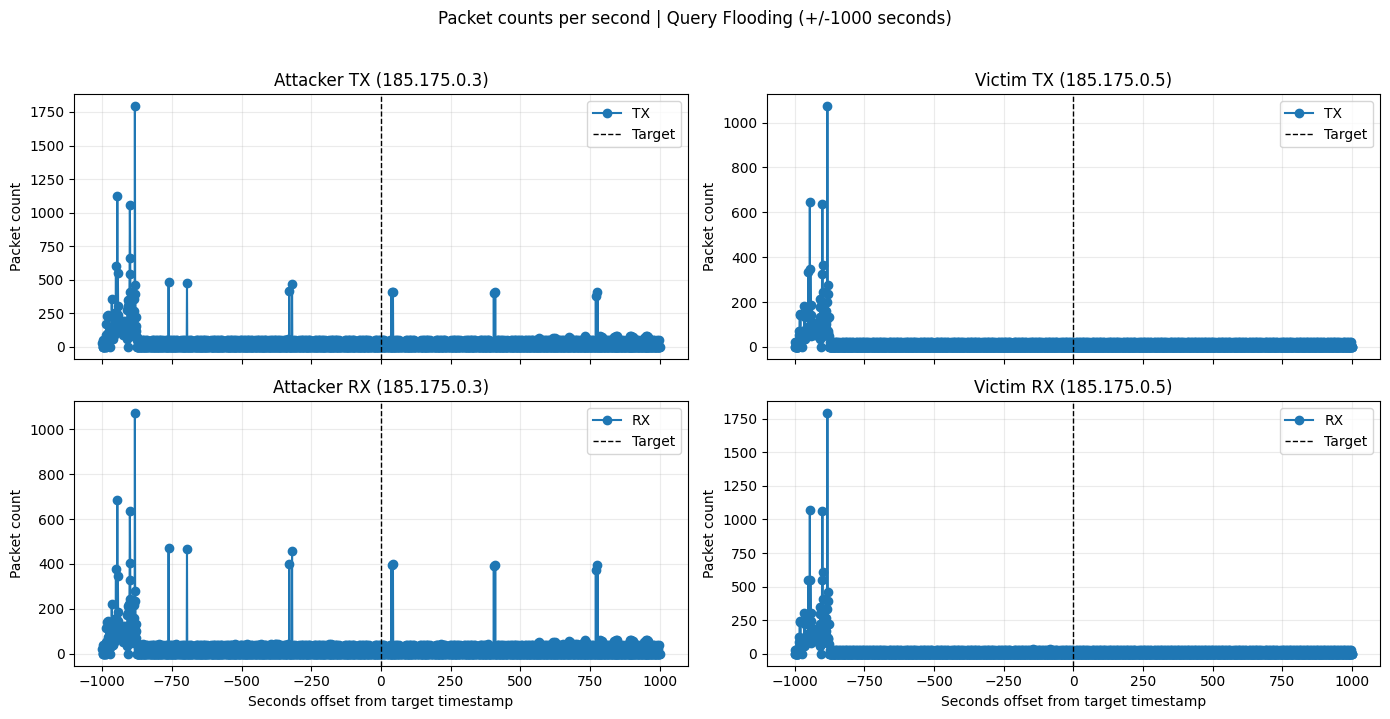

===== ATTACKER DEBUG =====
Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in +/-1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Packet counts per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX packet total: 56213
RX packet total: 39901
===== VICTIM DEBUG =====
Att

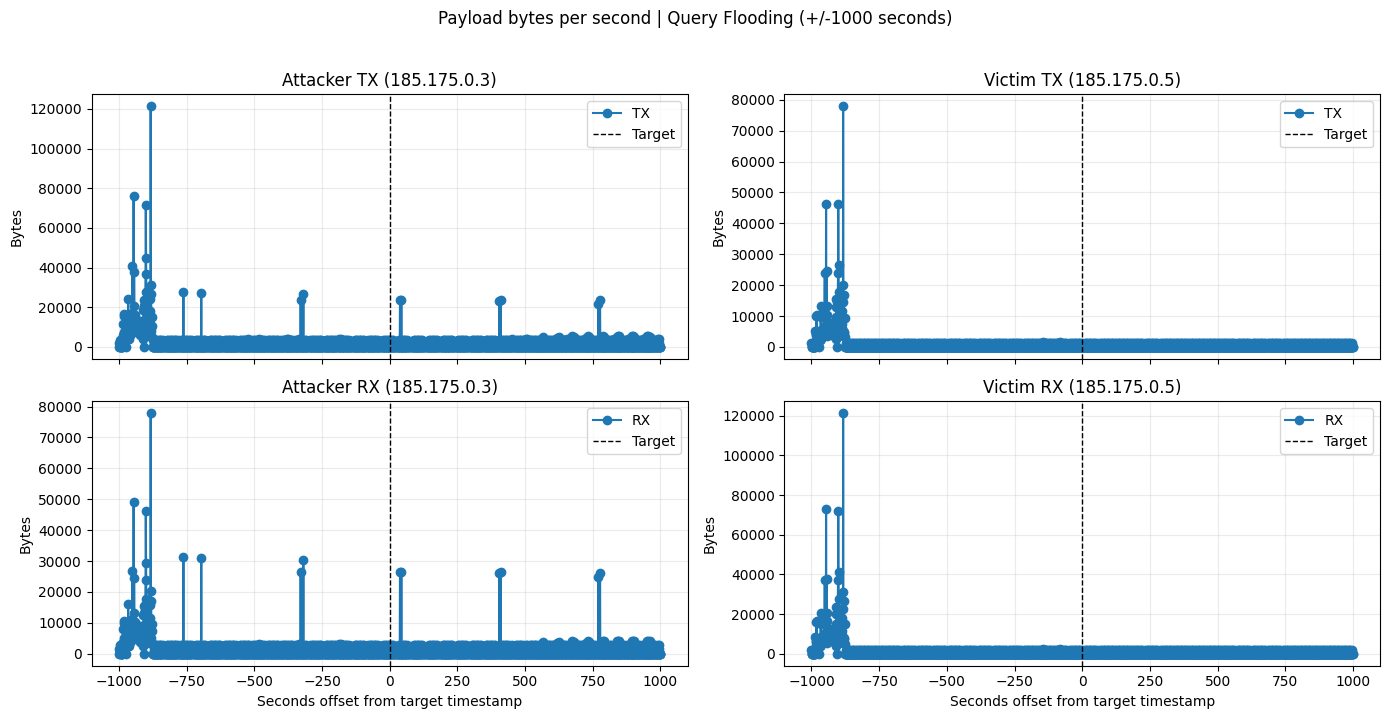

===== ATTACKER DEBUG =====
Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in +/-1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Payload bytes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX byte total: 3825266
RX byte total: 2818027
===== VICTIM DEBUG =====
Att

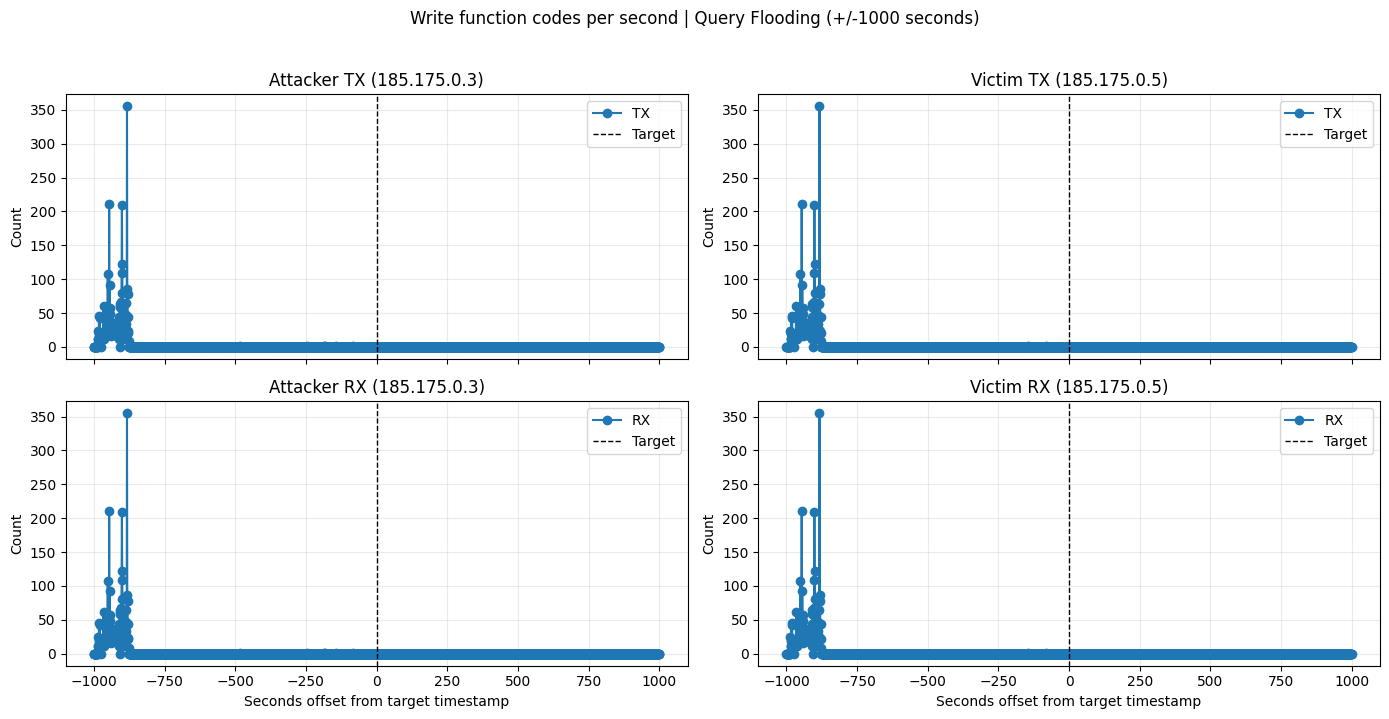

===== ATTACKER DEBUG =====
Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in +/-1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Write function codes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX write-code total: 4131
RX write-code total: 4131
===== VICTIM DE

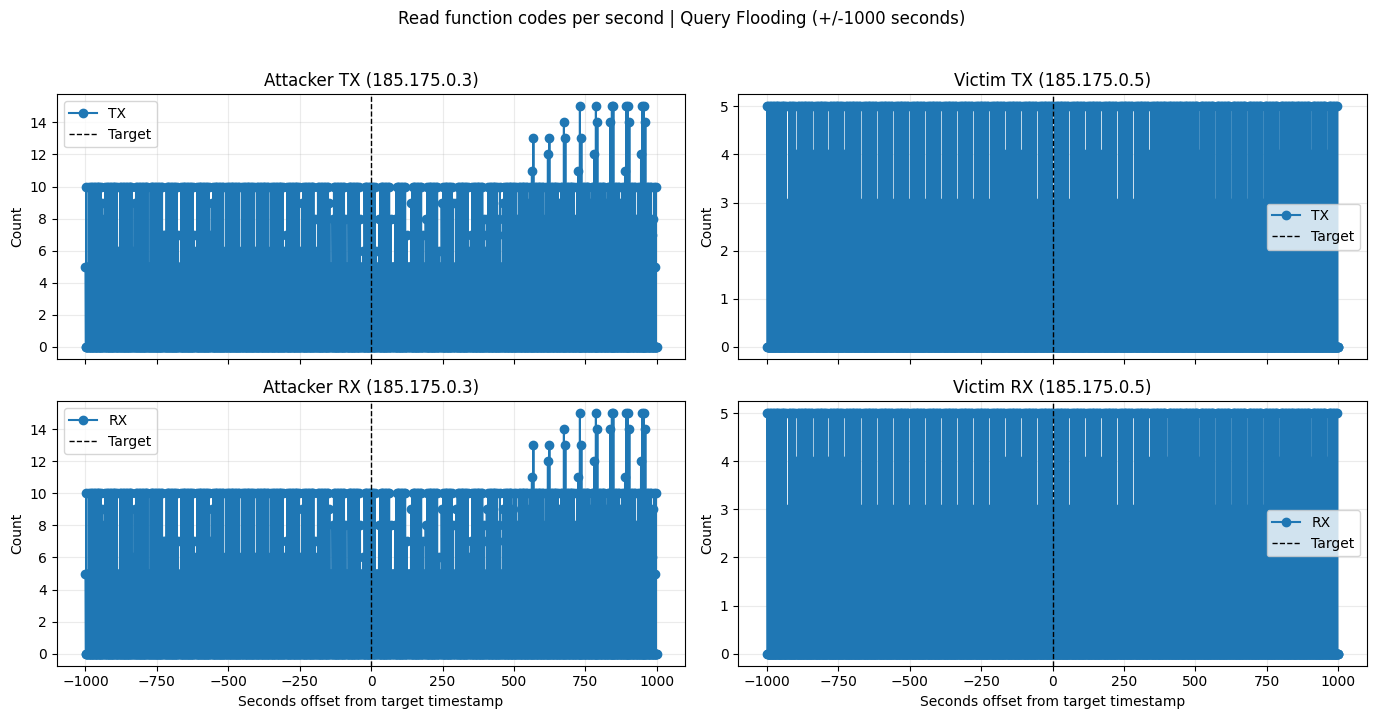

===== ATTACKER DEBUG =====
Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in +/-1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Read function codes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX read-code total: 5885
RX read-code total: 5885
===== VICTIM DEBUG

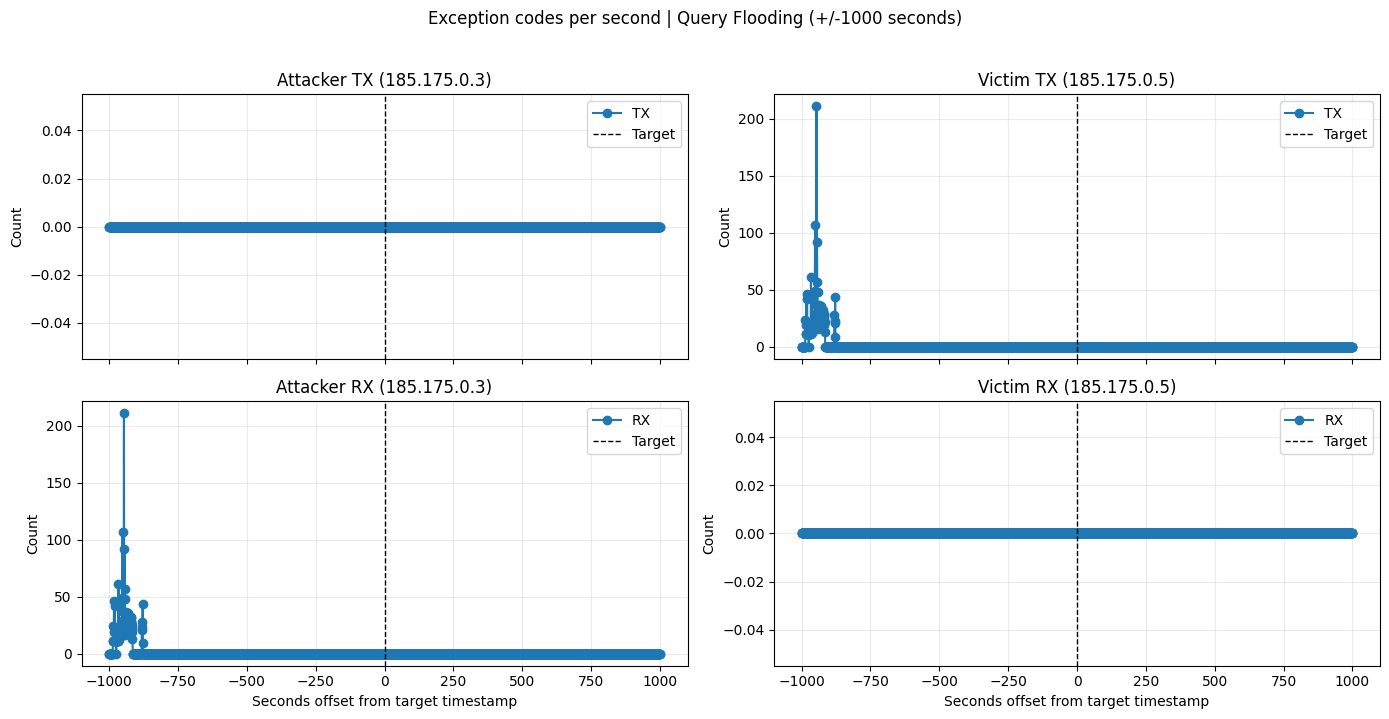

===== ATTACKER DEBUG =====
Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in +/-1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Exception codes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX exception total: 0
RX exception total: 2125
===== VICTIM DEBUG =====


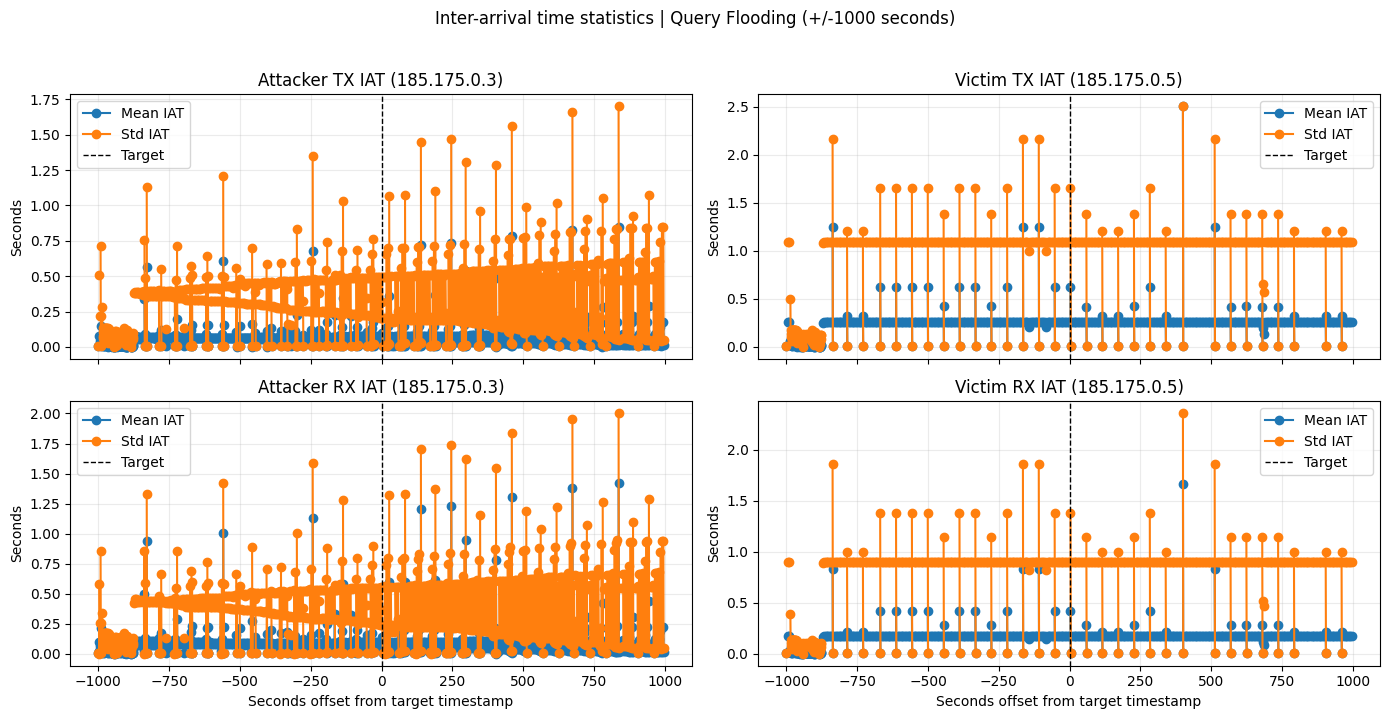

===== ATTACKER DEBUG =====
Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in +/-1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Inter-arrival time statistics
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX IAT count: 56212
RX IAT count: 39900
TX IAT mean: 0.035518
RX IAT 

In [10]:
wrapper(
    input_csv="../train/chunks/csc_9.csv",
    attacker_ip="185.175.0.3",
    victim_ip="185.175.0.5",
    timestamp="2023-03-18 20:35:45.019",
    attack_name="Query Flooding",
    time_range_seconds=1000,
    debug=True,
    time_offset_seconds=10800,
)

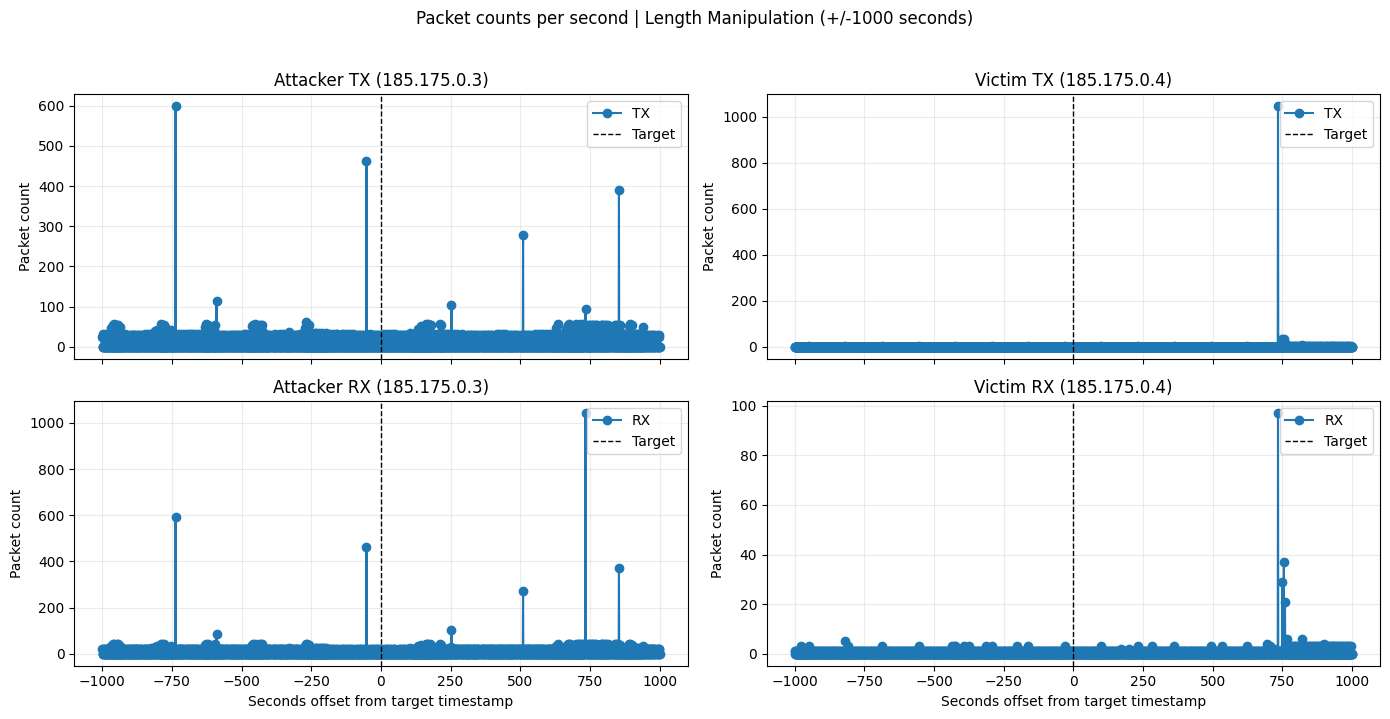

===== ATTACKER DEBUG =====
Attack name: Length Manipulation
Input CSV: ../train/chunks/csc_3.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 948863
Window: 2023-03-17 01:16:57.288000 -> 2023-03-17 01:50:17.288000
Rows in +/-1000 second window: 40001
Time offset applied: 10800 seconds
Metric: Packet counts per second
Target timestamp: 2023-03-17 01:33:37.288000
Window start in data: 2023-03-17 01:16:57.453340054
Window end in data:   2023-03-17 01:50:15.385205984
Nearest packet for this IP:
aligned_ts               2023-03-17 01:33:37.193223953
frame.time_epoch                     1679006017.193224
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.4
frame.len                                           74
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.094776
TX packet total: 22494
RX packet total: 17507
===== VICTIM DEBUG ====

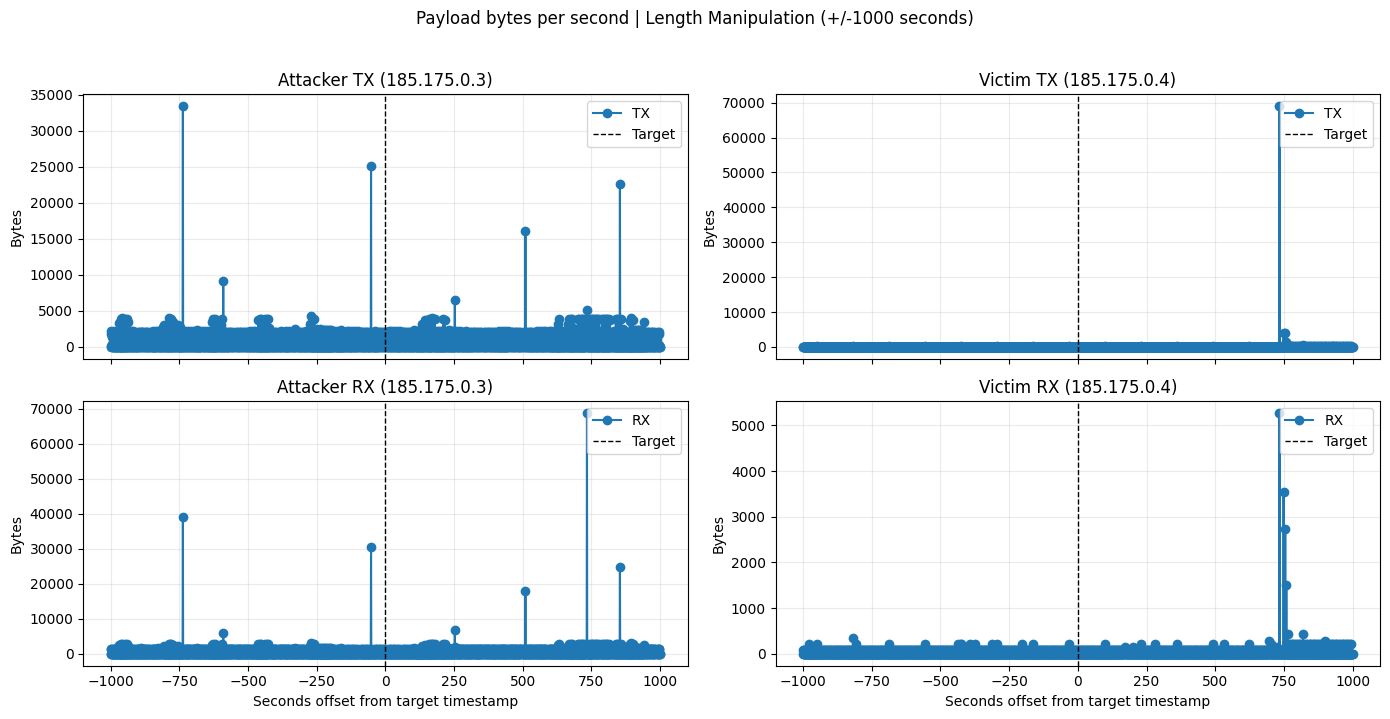

===== ATTACKER DEBUG =====
Attack name: Length Manipulation
Input CSV: ../train/chunks/csc_3.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 948863
Window: 2023-03-17 01:16:57.288000 -> 2023-03-17 01:50:17.288000
Rows in +/-1000 second window: 40001
Time offset applied: 10800 seconds
Metric: Payload bytes per second
Target timestamp: 2023-03-17 01:33:37.288000
Window start in data: 2023-03-17 01:16:57.453340054
Window end in data:   2023-03-17 01:50:15.385205984
Nearest packet for this IP:
aligned_ts               2023-03-17 01:33:37.193223953
frame.time_epoch                     1679006017.193224
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.4
frame.len                                           74
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.094776
TX byte total: 1544104
RX byte total: 1221525
===== VICTIM DEBUG ====

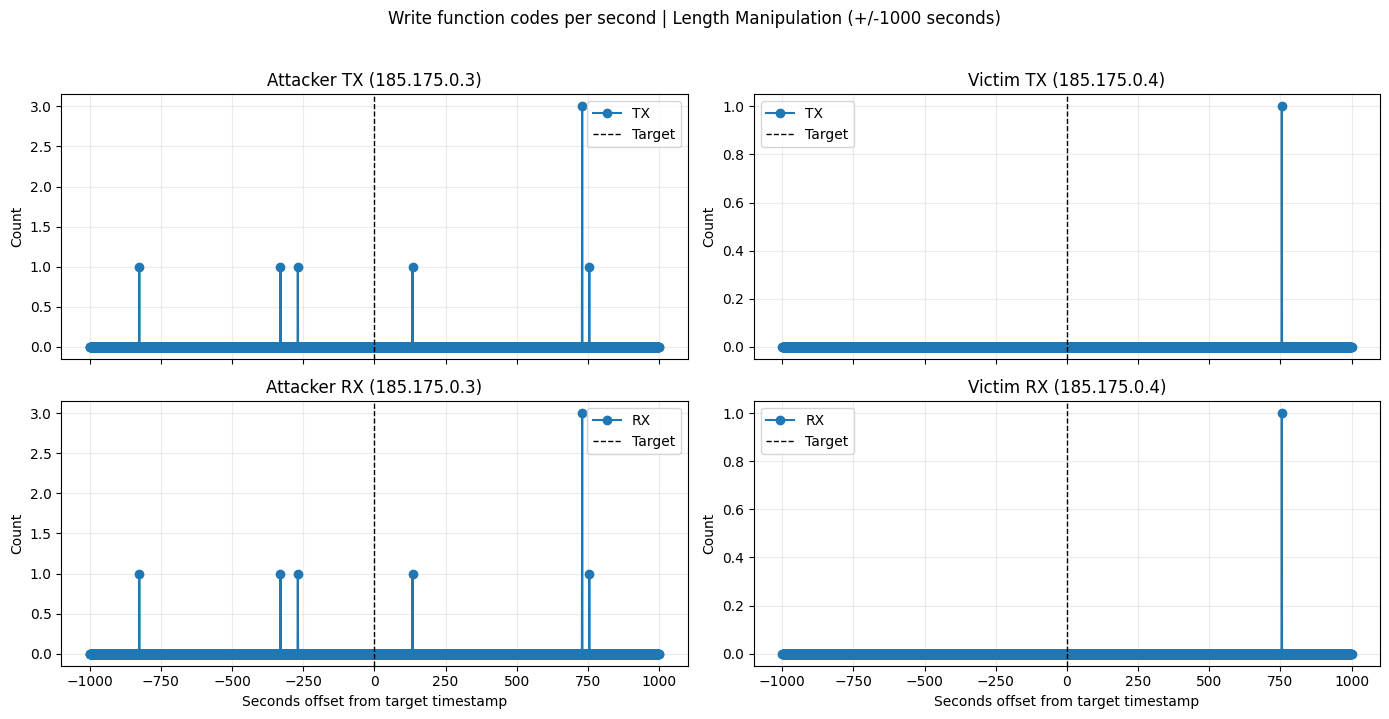

===== ATTACKER DEBUG =====
Attack name: Length Manipulation
Input CSV: ../train/chunks/csc_3.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 948863
Window: 2023-03-17 01:16:57.288000 -> 2023-03-17 01:50:17.288000
Rows in +/-1000 second window: 40001
Time offset applied: 10800 seconds
Metric: Write function codes per second
Target timestamp: 2023-03-17 01:33:37.288000
Window start in data: 2023-03-17 01:16:57.453340054
Window end in data:   2023-03-17 01:50:15.385205984
Nearest packet for this IP:
aligned_ts               2023-03-17 01:33:37.193223953
frame.time_epoch                     1679006017.193224
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.4
frame.len                                           74
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.094776
TX write-code total: 8
RX write-code total: 8
===== VICTIM DEB

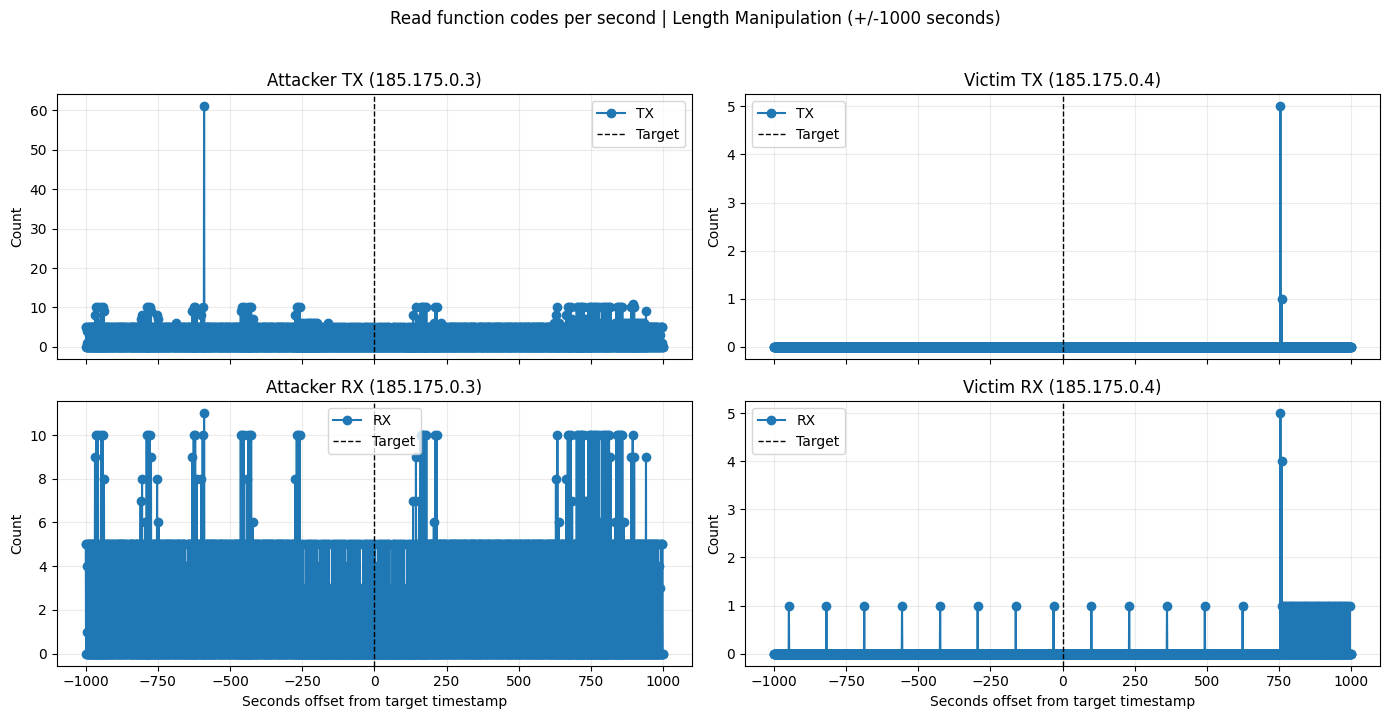

===== ATTACKER DEBUG =====
Attack name: Length Manipulation
Input CSV: ../train/chunks/csc_3.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 948863
Window: 2023-03-17 01:16:57.288000 -> 2023-03-17 01:50:17.288000
Rows in +/-1000 second window: 40001
Time offset applied: 10800 seconds
Metric: Read function codes per second
Target timestamp: 2023-03-17 01:33:37.288000
Window start in data: 2023-03-17 01:16:57.453340054
Window end in data:   2023-03-17 01:50:15.385205984
Nearest packet for this IP:
aligned_ts               2023-03-17 01:33:37.193223953
frame.time_epoch                     1679006017.193224
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.4
frame.len                                           74
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.094776
TX read-code total: 3711
RX read-code total: 3524
===== VICTIM 

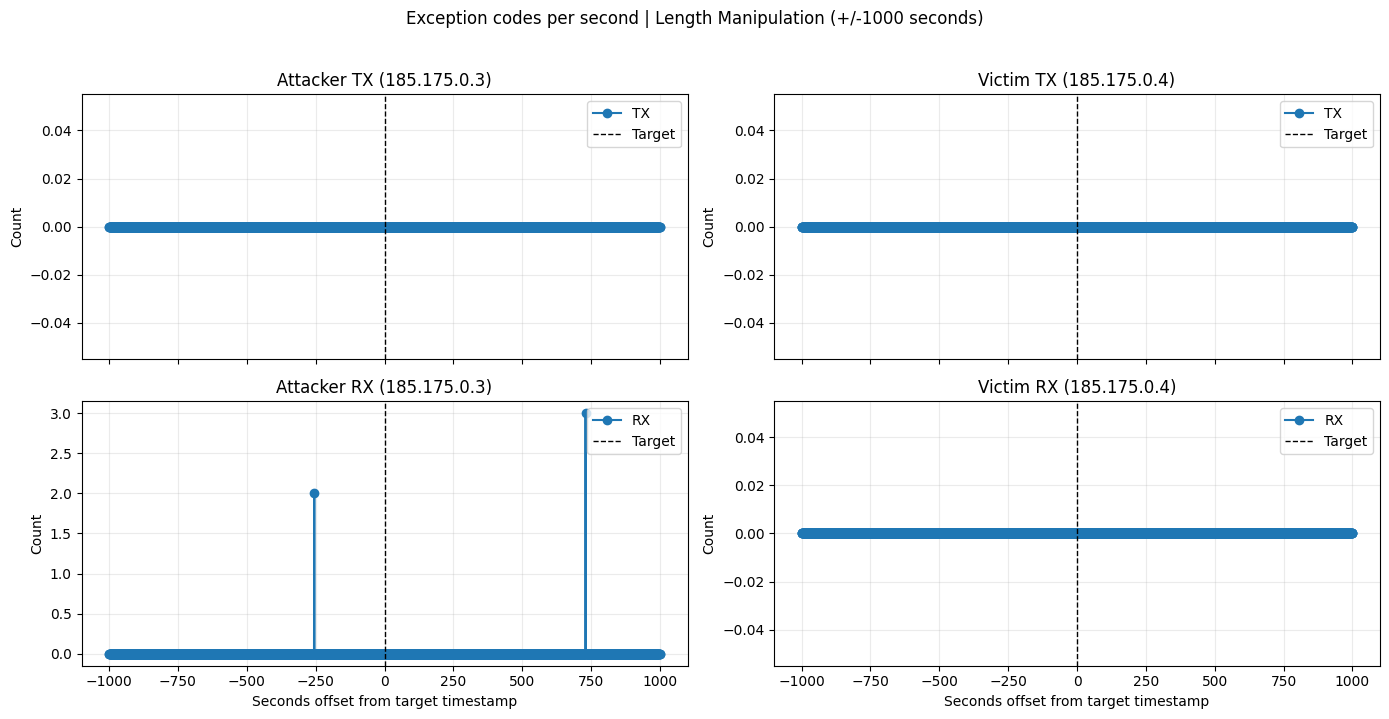

===== ATTACKER DEBUG =====
Attack name: Length Manipulation
Input CSV: ../train/chunks/csc_3.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 948863
Window: 2023-03-17 01:16:57.288000 -> 2023-03-17 01:50:17.288000
Rows in +/-1000 second window: 40001
Time offset applied: 10800 seconds
Metric: Exception codes per second
Target timestamp: 2023-03-17 01:33:37.288000
Window start in data: 2023-03-17 01:16:57.453340054
Window end in data:   2023-03-17 01:50:15.385205984
Nearest packet for this IP:
aligned_ts               2023-03-17 01:33:37.193223953
frame.time_epoch                     1679006017.193224
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.4
frame.len                                           74
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.094776
TX exception total: 0
RX exception total: 5
===== VICTIM DEBUG ====

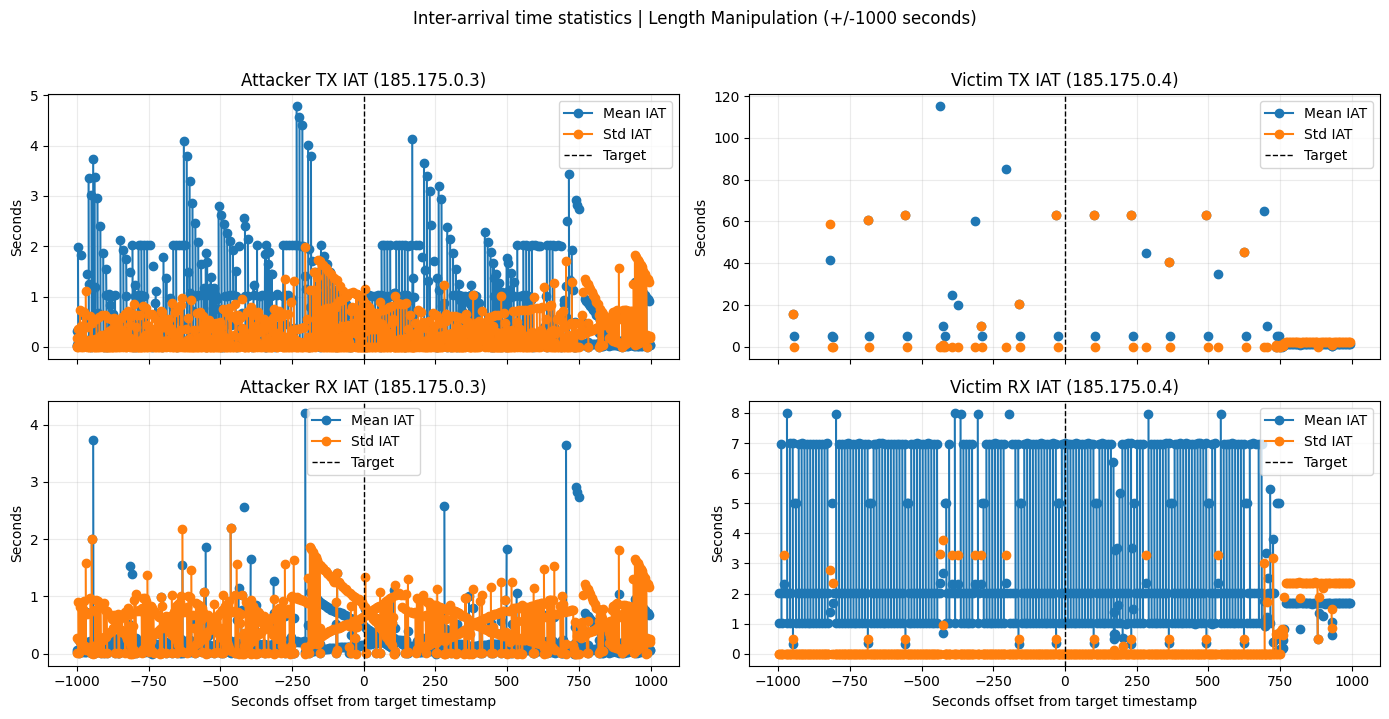

===== ATTACKER DEBUG =====
Attack name: Length Manipulation
Input CSV: ../train/chunks/csc_3.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 948863
Window: 2023-03-17 01:16:57.288000 -> 2023-03-17 01:50:17.288000
Rows in +/-1000 second window: 40001
Time offset applied: 10800 seconds
Metric: Inter-arrival time statistics
Target timestamp: 2023-03-17 01:33:37.288000
Window start in data: 2023-03-17 01:16:57.453340054
Window end in data:   2023-03-17 01:50:15.385205984
Nearest packet for this IP:
aligned_ts               2023-03-17 01:33:37.193223953
frame.time_epoch                     1679006017.193224
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.4
frame.len                                           74
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.094776
TX IAT count: 22493
RX IAT count: 17506
TX IAT mean: 0.088823
RX

In [6]:
wrapper(
    input_csv="../train/chunks/csc_3.csv",
    attacker_ip="185.175.0.3",
    victim_ip="185.175.0.4",
    timestamp="2023-03-17 01:33:37.288",
    attack_name="Length Manipulation",
    time_range_seconds=1000,
    debug=True,
    time_offset_seconds=10800,
)

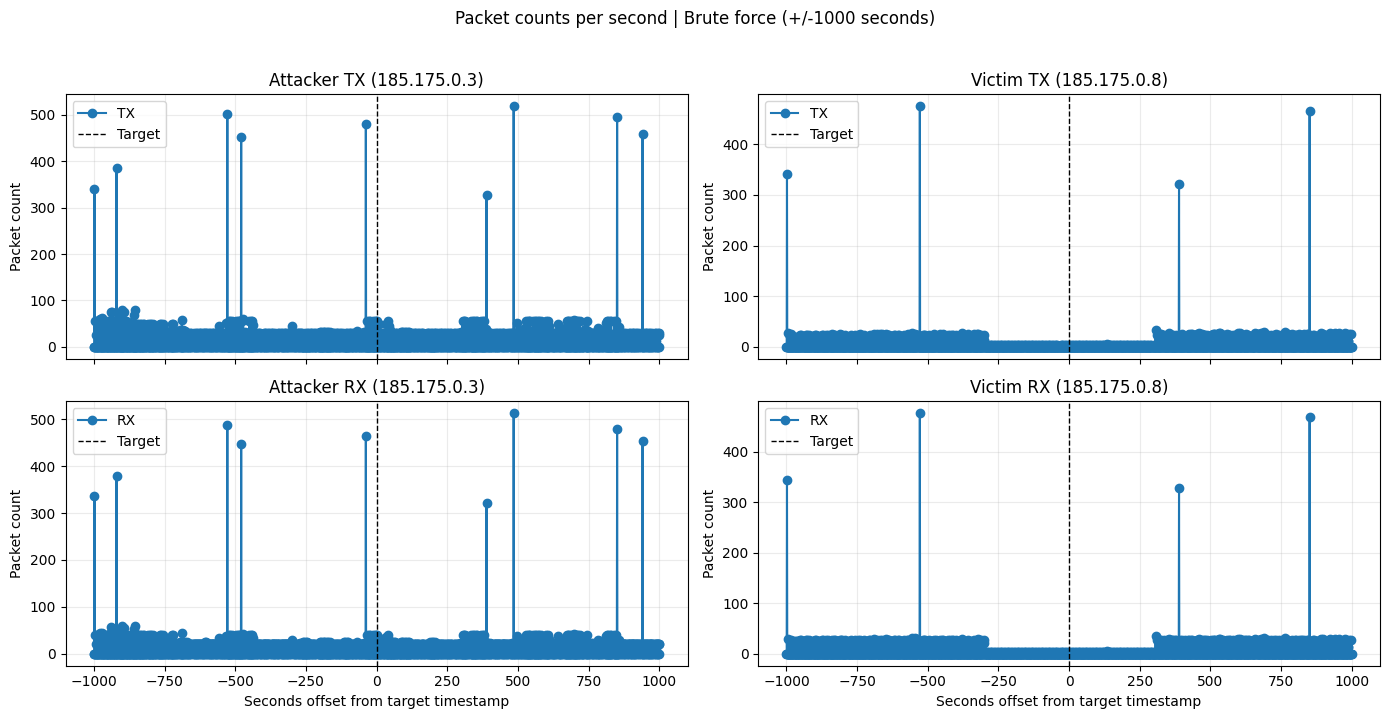

===== ATTACKER DEBUG =====
Attack name: Brute force
Input CSV: ../train/chunks/csc_4.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 962077
Window: 2023-03-17 04:21:43.131000 -> 2023-03-17 04:55:03.131000
Rows in +/-1000 second window: 57702
Time offset applied: 10800 seconds
Metric: Packet counts per second
Target timestamp: 2023-03-17 04:38:23.131000
Window start in data: 2023-03-17 04:21:45.041755915
Window end in data:   2023-03-17 04:55:02.464461088
Nearest packet for this IP:
aligned_ts               2023-03-17 04:38:23.085310936
frame.time_epoch                     1679017103.085311
ip.src                                     185.175.0.8
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.045689
TX packet total: 32441
RX packet total: 25261
===== VICTIM DEBUG =====
Attack

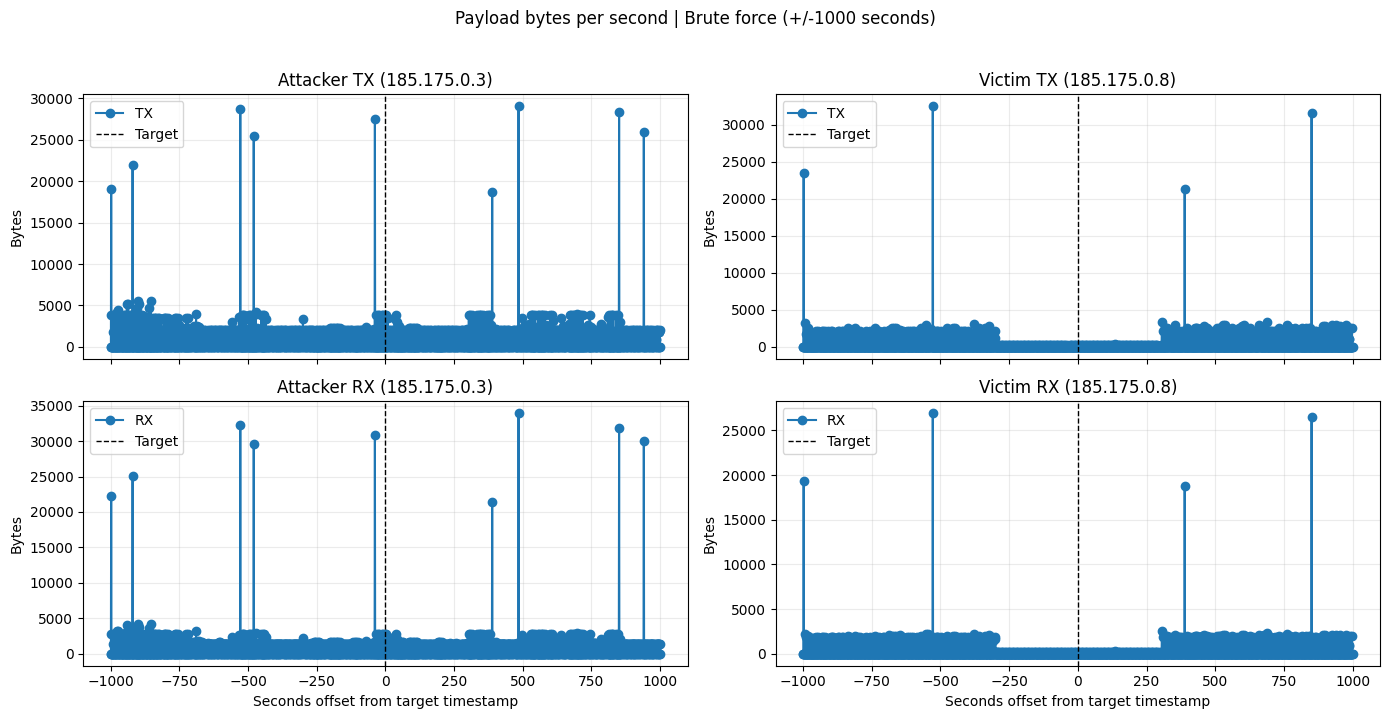

===== ATTACKER DEBUG =====
Attack name: Brute force
Input CSV: ../train/chunks/csc_4.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 962077
Window: 2023-03-17 04:21:43.131000 -> 2023-03-17 04:55:03.131000
Rows in +/-1000 second window: 57702
Time offset applied: 10800 seconds
Metric: Payload bytes per second
Target timestamp: 2023-03-17 04:38:23.131000
Window start in data: 2023-03-17 04:21:45.041755915
Window end in data:   2023-03-17 04:55:02.464461088
Nearest packet for this IP:
aligned_ts               2023-03-17 04:38:23.085310936
frame.time_epoch                     1679017103.085311
ip.src                                     185.175.0.8
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.045689
TX byte total: 2211086
RX byte total: 1765212
===== VICTIM DEBUG =====
Attack

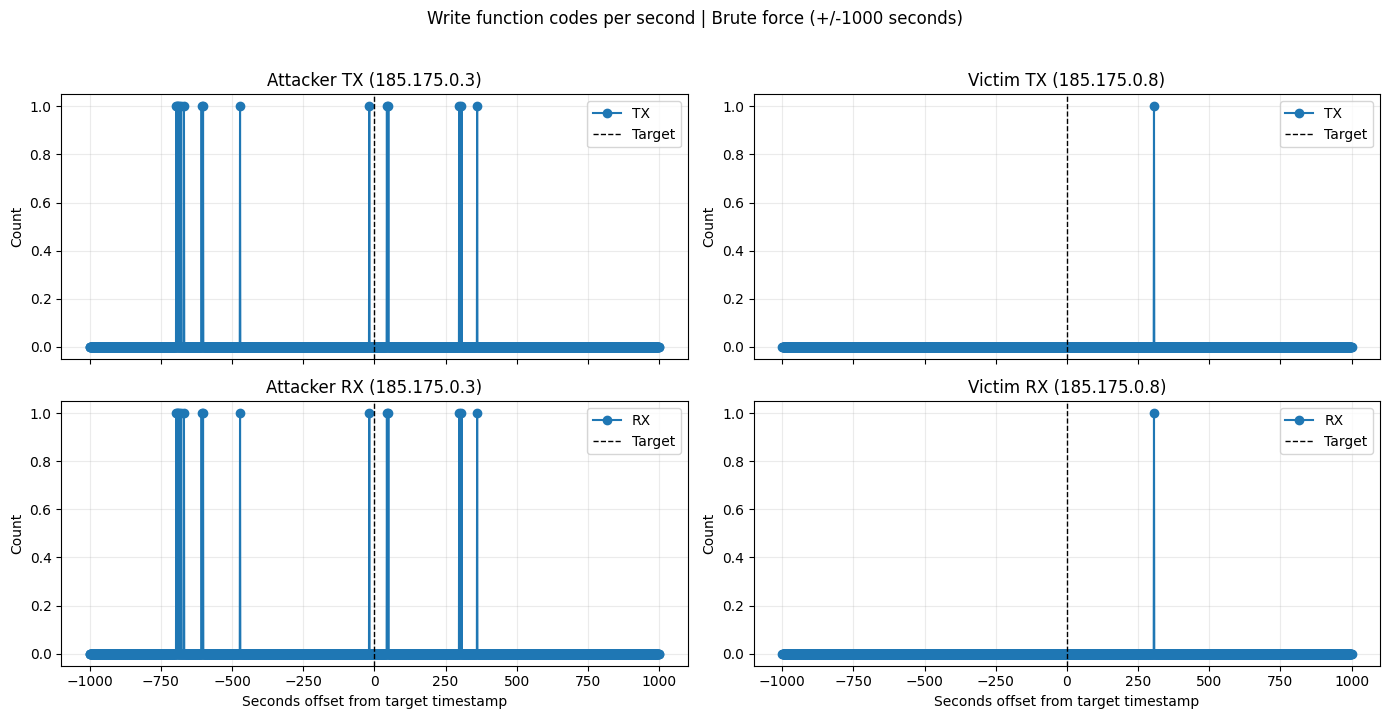

===== ATTACKER DEBUG =====
Attack name: Brute force
Input CSV: ../train/chunks/csc_4.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 962077
Window: 2023-03-17 04:21:43.131000 -> 2023-03-17 04:55:03.131000
Rows in +/-1000 second window: 57702
Time offset applied: 10800 seconds
Metric: Write function codes per second
Target timestamp: 2023-03-17 04:38:23.131000
Window start in data: 2023-03-17 04:21:45.041755915
Window end in data:   2023-03-17 04:55:02.464461088
Nearest packet for this IP:
aligned_ts               2023-03-17 04:38:23.085310936
frame.time_epoch                     1679017103.085311
ip.src                                     185.175.0.8
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.045689
TX write-code total: 15
RX write-code total: 15
===== VICTIM DEBUG ===

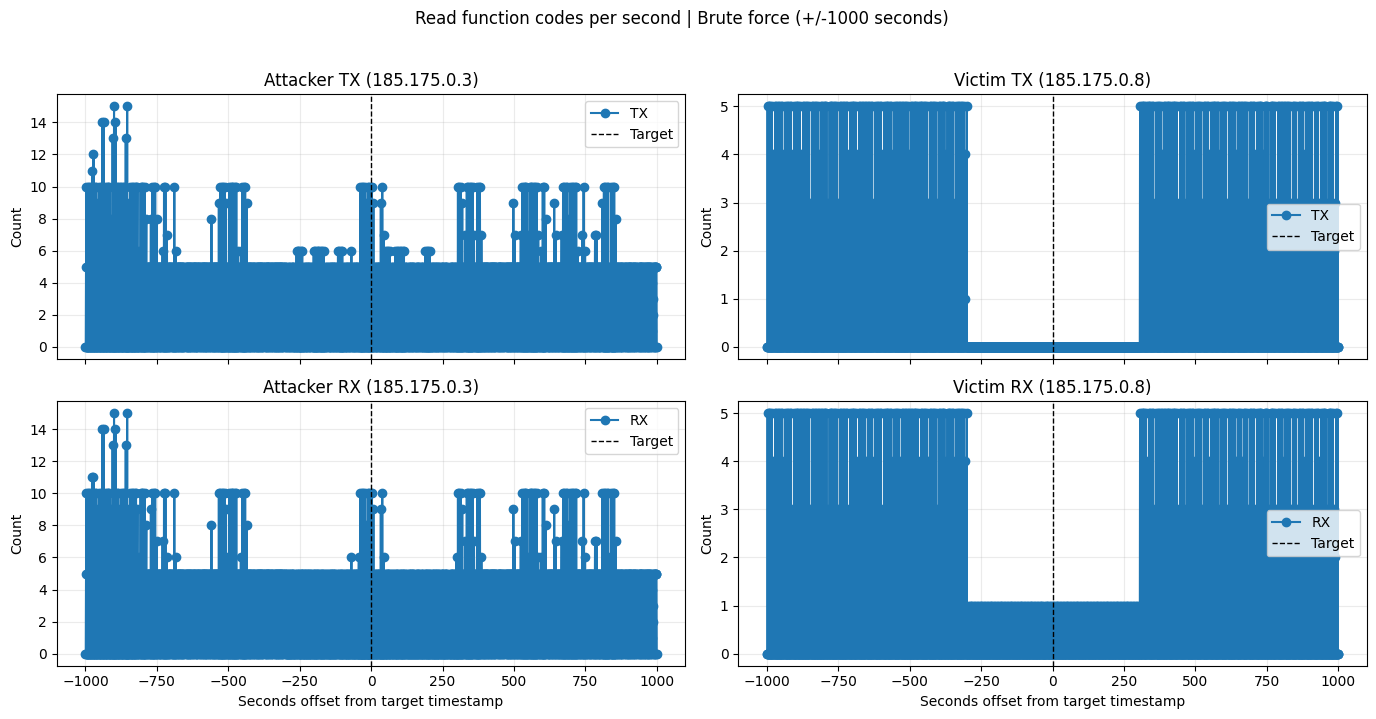

===== ATTACKER DEBUG =====
Attack name: Brute force
Input CSV: ../train/chunks/csc_4.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 962077
Window: 2023-03-17 04:21:43.131000 -> 2023-03-17 04:55:03.131000
Rows in +/-1000 second window: 57702
Time offset applied: 10800 seconds
Metric: Read function codes per second
Target timestamp: 2023-03-17 04:38:23.131000
Window start in data: 2023-03-17 04:21:45.041755915
Window end in data:   2023-03-17 04:55:02.464461088
Nearest packet for this IP:
aligned_ts               2023-03-17 04:38:23.085310936
frame.time_epoch                     1679017103.085311
ip.src                                     185.175.0.8
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.045689
TX read-code total: 5369
RX read-code total: 5249
===== VICTIM DEBUG ==

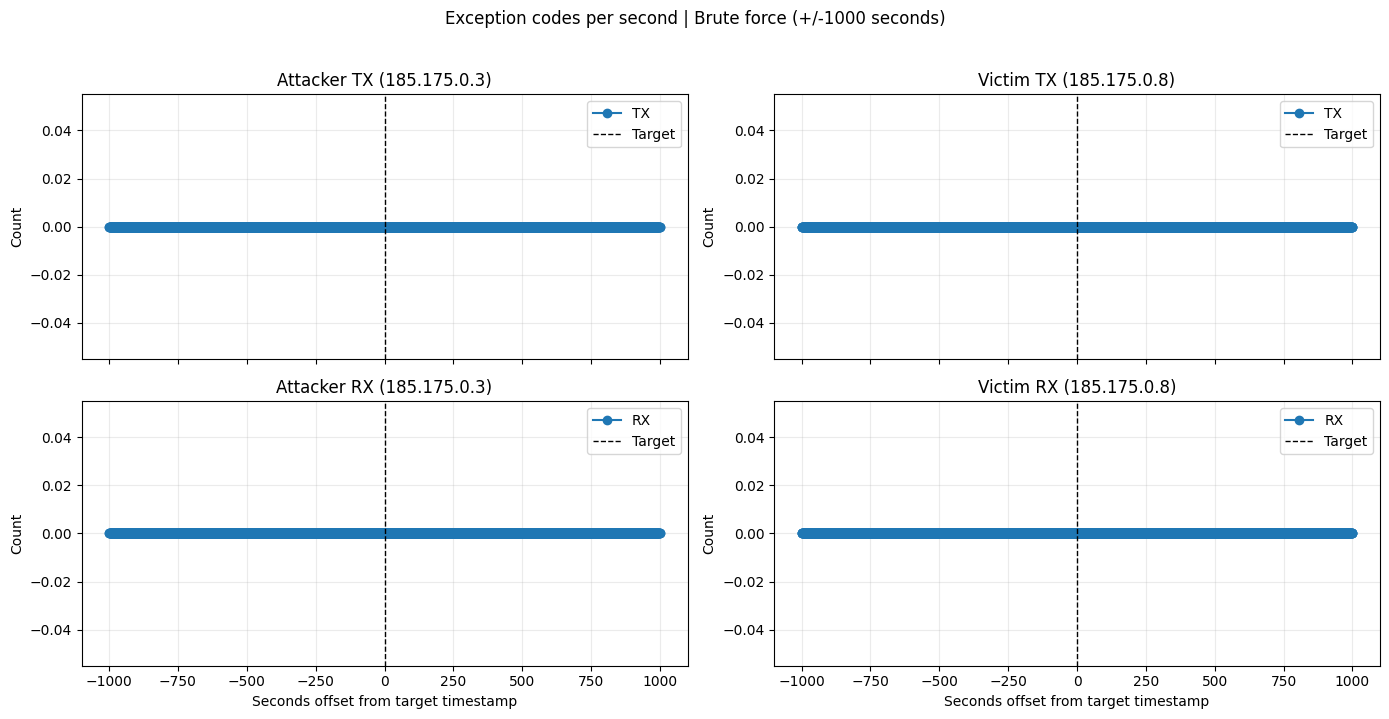

===== ATTACKER DEBUG =====
Attack name: Brute force
Input CSV: ../train/chunks/csc_4.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 962077
Window: 2023-03-17 04:21:43.131000 -> 2023-03-17 04:55:03.131000
Rows in +/-1000 second window: 57702
Time offset applied: 10800 seconds
Metric: Exception codes per second
Target timestamp: 2023-03-17 04:38:23.131000
Window start in data: 2023-03-17 04:21:45.041755915
Window end in data:   2023-03-17 04:55:02.464461088
Nearest packet for this IP:
aligned_ts               2023-03-17 04:38:23.085310936
frame.time_epoch                     1679017103.085311
ip.src                                     185.175.0.8
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.045689
TX exception total: 0
RX exception total: 0
===== VICTIM DEBUG =====
Attack

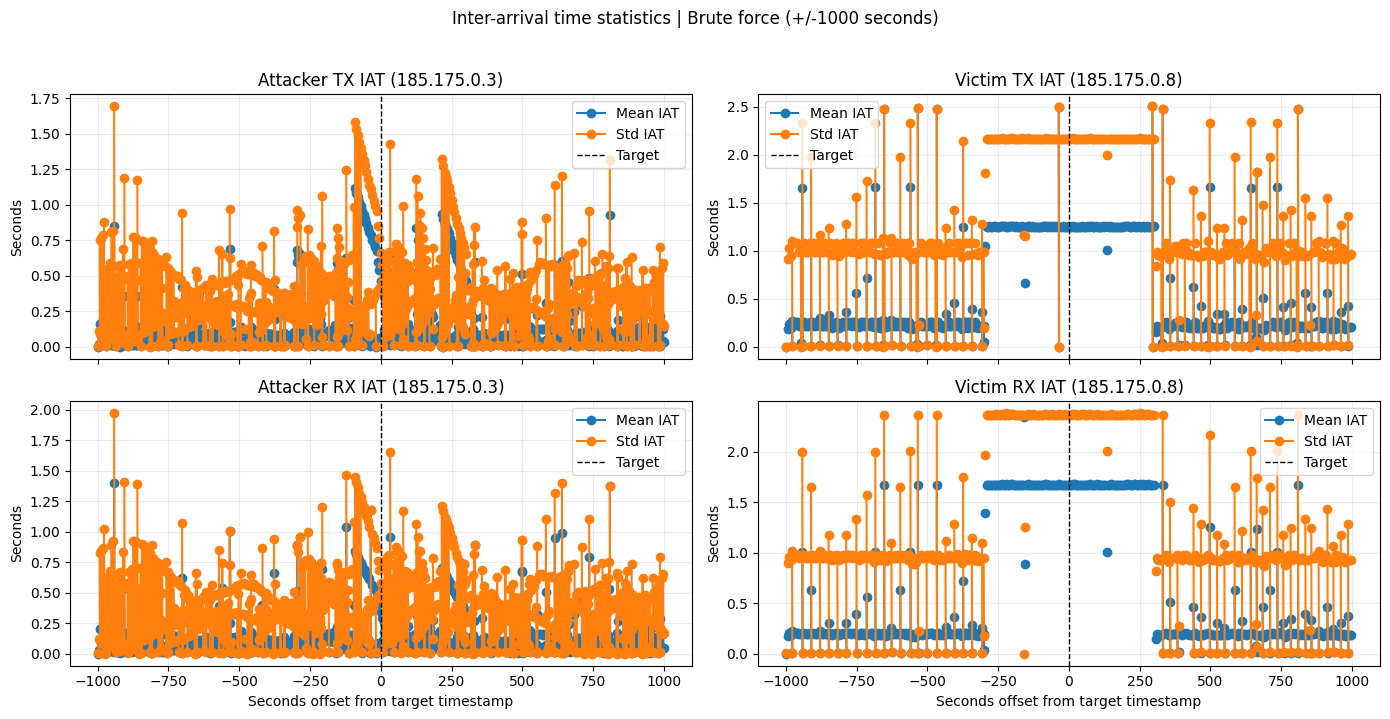

===== ATTACKER DEBUG =====
Attack name: Brute force
Input CSV: ../train/chunks/csc_4.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 962077
Window: 2023-03-17 04:21:43.131000 -> 2023-03-17 04:55:03.131000
Rows in +/-1000 second window: 57702
Time offset applied: 10800 seconds
Metric: Inter-arrival time statistics
Target timestamp: 2023-03-17 04:38:23.131000
Window start in data: 2023-03-17 04:21:45.041755915
Window end in data:   2023-03-17 04:55:02.464461088
Nearest packet for this IP:
aligned_ts               2023-03-17 04:38:23.085310936
frame.time_epoch                     1679017103.085311
ip.src                                     185.175.0.8
ip.dst                                     185.175.0.3
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.045689
TX IAT count: 32440
RX IAT count: 25260
TX IAT mean: 0.061573
RX IAT mea

In [5]:
wrapper(
    input_csv="../train/chunks/csc_4.csv",
    attacker_ip="185.175.0.3",
    victim_ip="185.175.0.8",
    timestamp="2023-03-17 04:38:23.131",
    attack_name="Brute force",
    time_range_seconds=1000,
    debug=True,
    time_offset_seconds=10800,
)

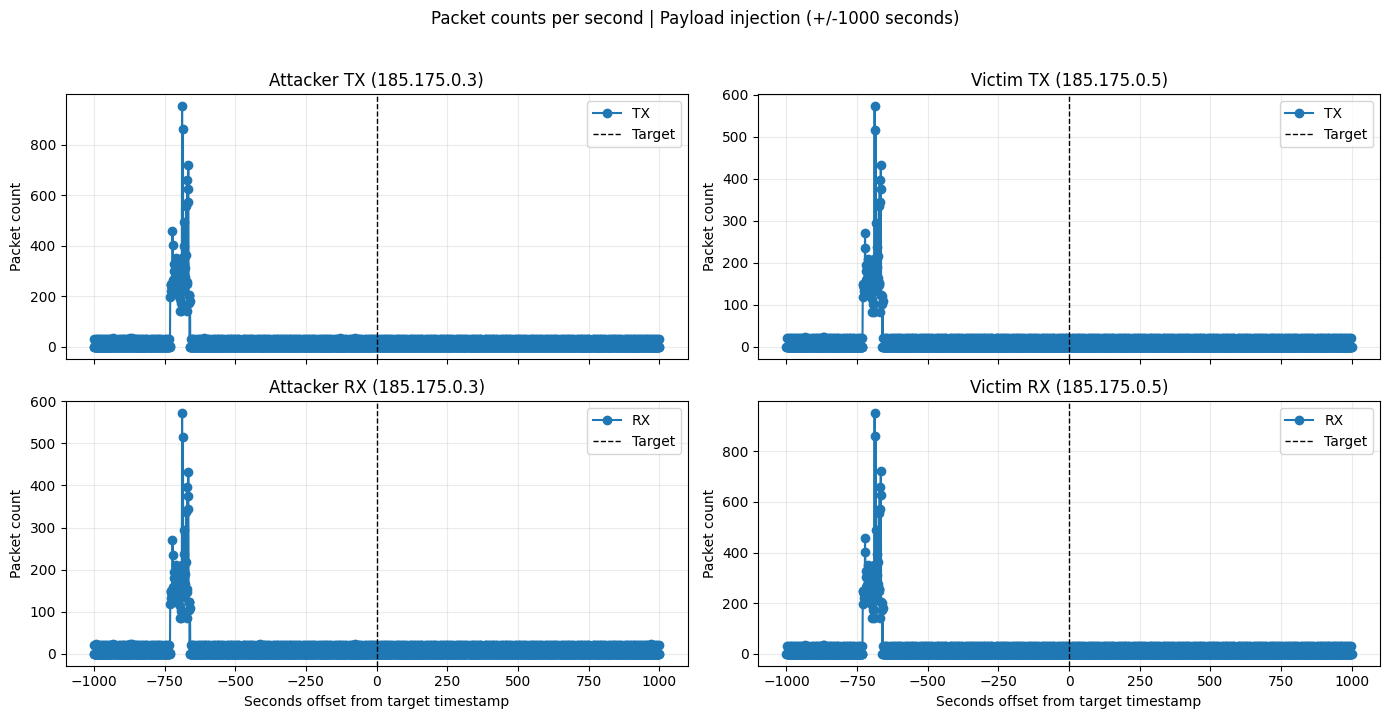

===== ATTACKER DEBUG =====
Attack name: Payload injection
Input CSV: ../train/chunks/csc_12.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981470
Window: 2023-03-20 00:26:01.318000 -> 2023-03-20 00:59:21.318000
Rows in +/-1000 second window: 54390
Time offset applied: 10800 seconds
Metric: Packet counts per second
Target timestamp: 2023-03-20 00:42:41.318000
Window start in data: 2023-03-20 00:26:02.449352026
Window end in data:   2023-03-20 00:59:20.105217934
Nearest packet for this IP:
aligned_ts               2023-03-20 00:42:40.928183079
frame.time_epoch                     1679262160.928183
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.389817
TX packet total: 33935
RX packet total: 20455
===== VICTIM DEBUG =====

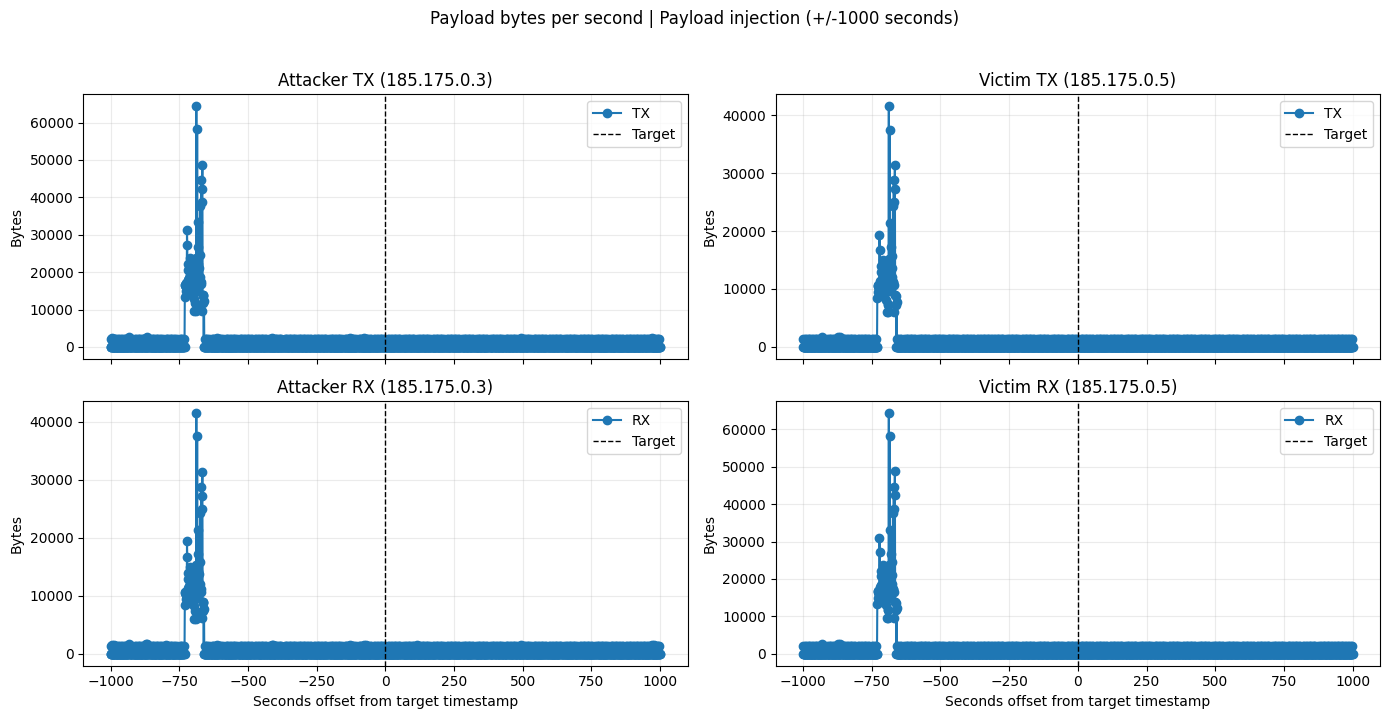

===== ATTACKER DEBUG =====
Attack name: Payload injection
Input CSV: ../train/chunks/csc_12.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981470
Window: 2023-03-20 00:26:01.318000 -> 2023-03-20 00:59:21.318000
Rows in +/-1000 second window: 54390
Time offset applied: 10800 seconds
Metric: Payload bytes per second
Target timestamp: 2023-03-20 00:42:41.318000
Window start in data: 2023-03-20 00:26:02.449352026
Window end in data:   2023-03-20 00:59:20.105217934
Nearest packet for this IP:
aligned_ts               2023-03-20 00:42:40.928183079
frame.time_epoch                     1679262160.928183
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.389817
TX byte total: 2323134
RX byte total: 1462671
===== VICTIM DEBUG =====

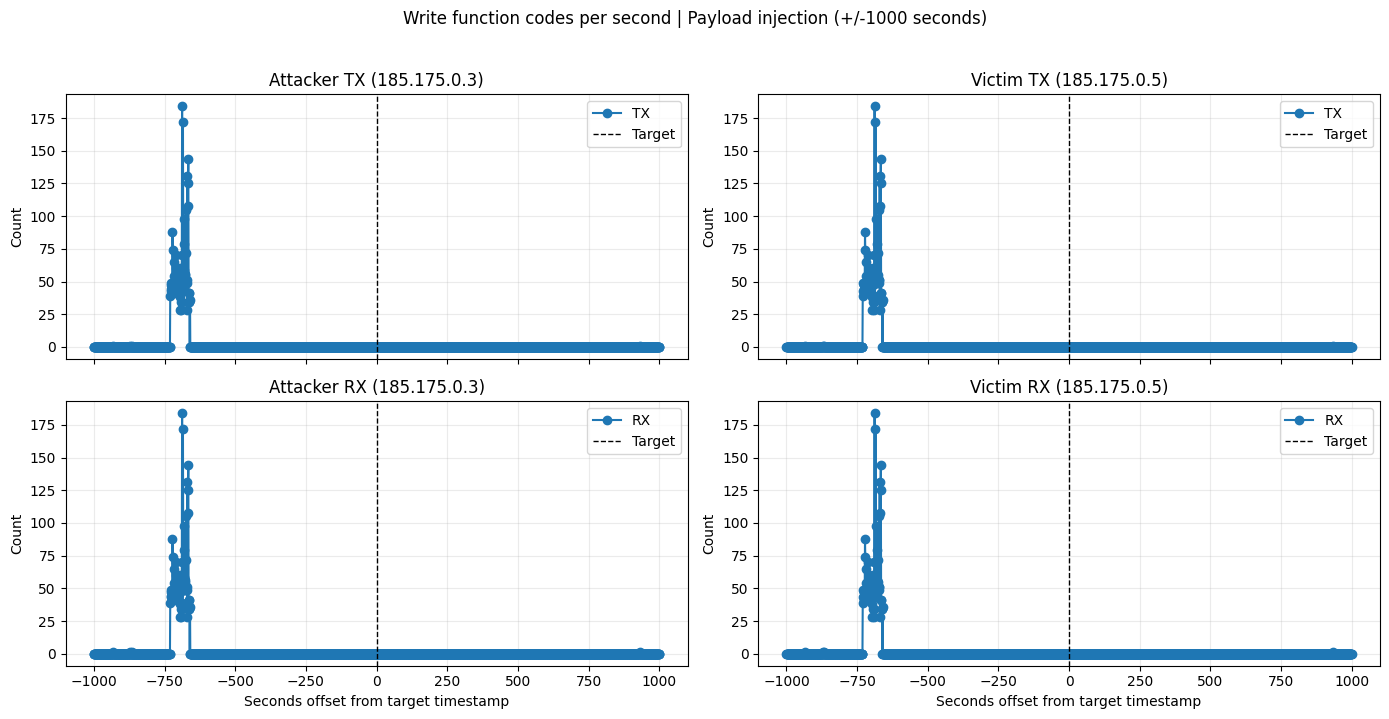

===== ATTACKER DEBUG =====
Attack name: Payload injection
Input CSV: ../train/chunks/csc_12.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981470
Window: 2023-03-20 00:26:01.318000 -> 2023-03-20 00:59:21.318000
Rows in +/-1000 second window: 54390
Time offset applied: 10800 seconds
Metric: Write function codes per second
Target timestamp: 2023-03-20 00:42:41.318000
Window start in data: 2023-03-20 00:26:02.449352026
Window end in data:   2023-03-20 00:59:20.105217934
Nearest packet for this IP:
aligned_ts               2023-03-20 00:42:40.928183079
frame.time_epoch                     1679262160.928183
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.389817
TX write-code total: 4129
RX write-code total: 4129
===== VICTI

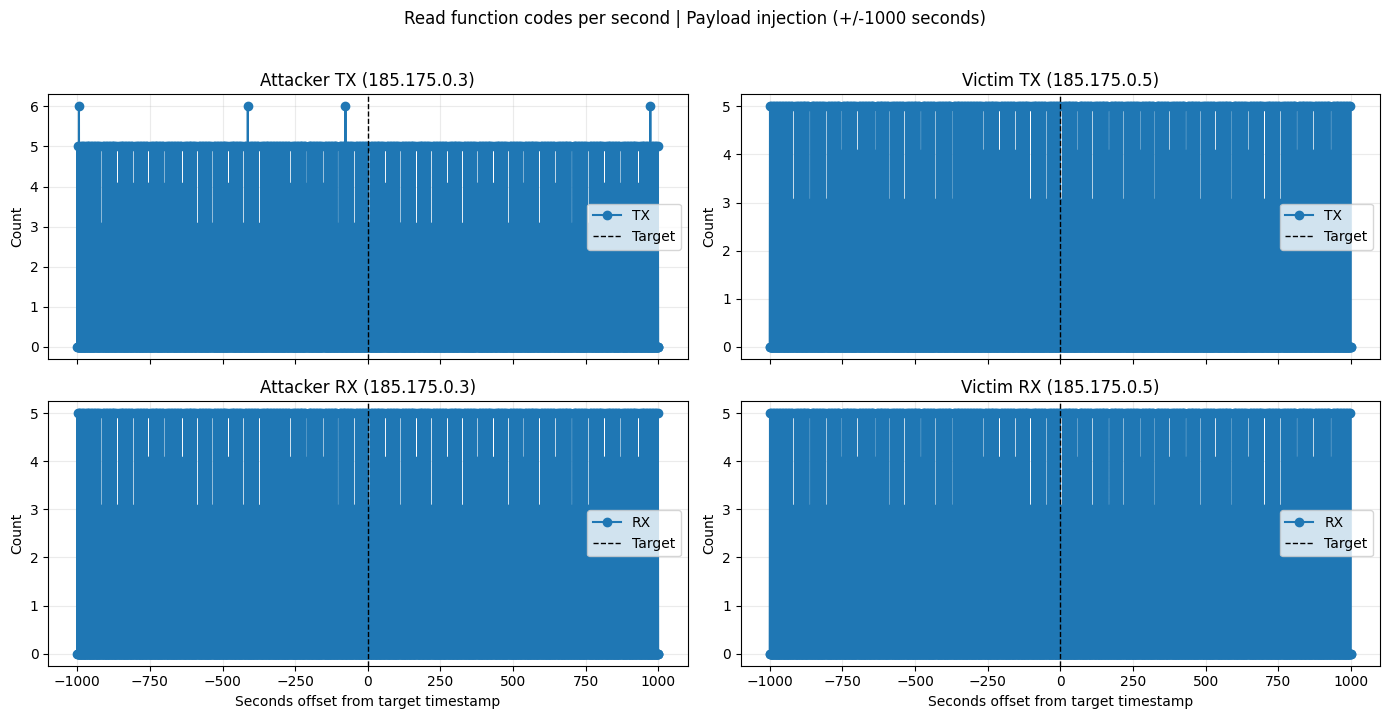

===== ATTACKER DEBUG =====
Attack name: Payload injection
Input CSV: ../train/chunks/csc_12.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981470
Window: 2023-03-20 00:26:01.318000 -> 2023-03-20 00:59:21.318000
Rows in +/-1000 second window: 54390
Time offset applied: 10800 seconds
Metric: Read function codes per second
Target timestamp: 2023-03-20 00:42:41.318000
Window start in data: 2023-03-20 00:26:02.449352026
Window end in data:   2023-03-20 00:59:20.105217934
Nearest packet for this IP:
aligned_ts               2023-03-20 00:42:40.928183079
frame.time_epoch                     1679262160.928183
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.389817
TX read-code total: 1996
RX read-code total: 1965
===== VICTIM D

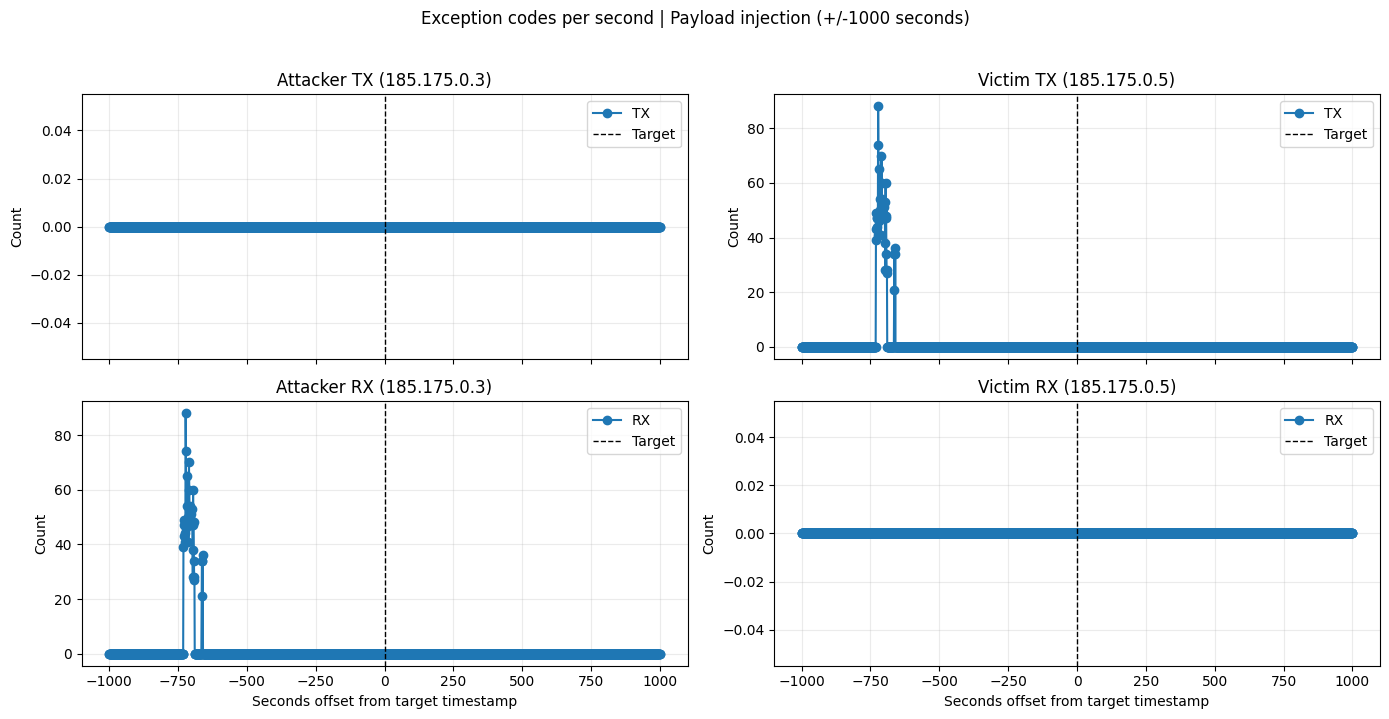

===== ATTACKER DEBUG =====
Attack name: Payload injection
Input CSV: ../train/chunks/csc_12.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981470
Window: 2023-03-20 00:26:01.318000 -> 2023-03-20 00:59:21.318000
Rows in +/-1000 second window: 54390
Time offset applied: 10800 seconds
Metric: Exception codes per second
Target timestamp: 2023-03-20 00:42:41.318000
Window start in data: 2023-03-20 00:26:02.449352026
Window end in data:   2023-03-20 00:59:20.105217934
Nearest packet for this IP:
aligned_ts               2023-03-20 00:42:40.928183079
frame.time_epoch                     1679262160.928183
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.389817
TX exception total: 0
RX exception total: 2125
===== VICTIM DEBUG ==

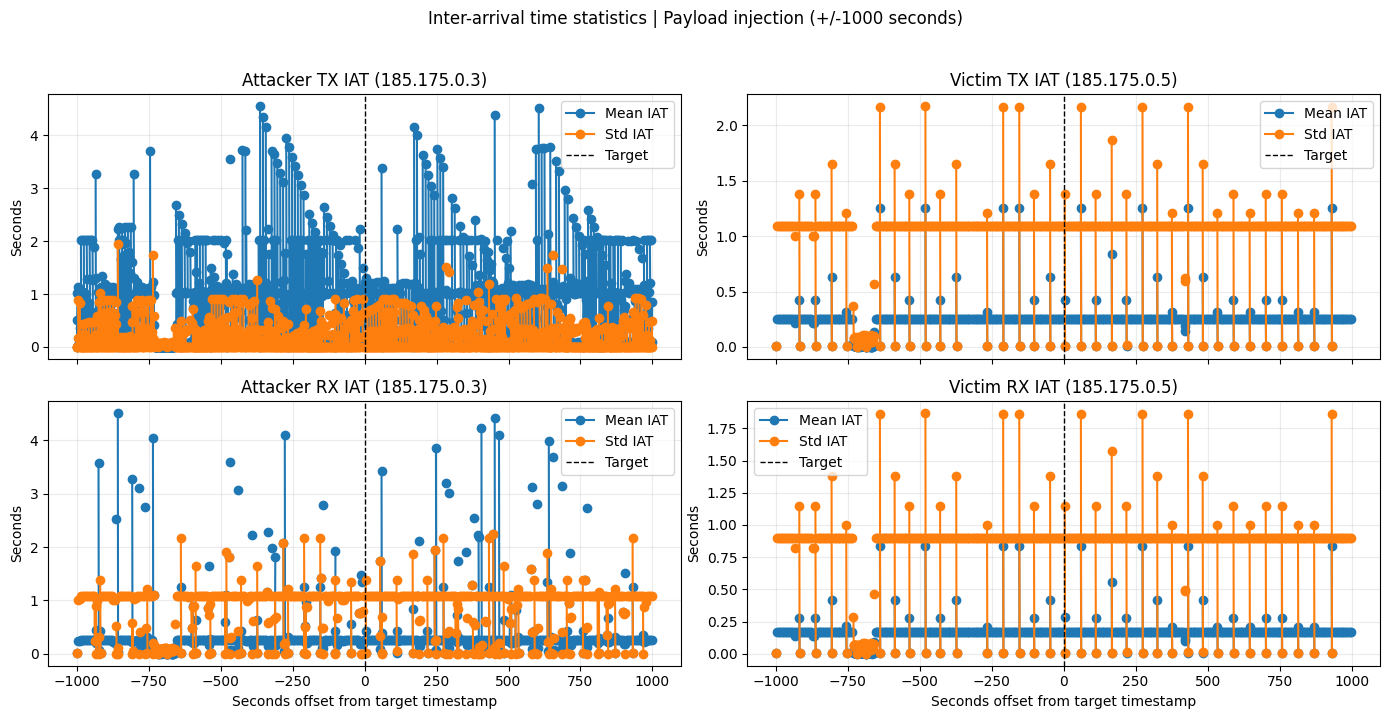

===== ATTACKER DEBUG =====
Attack name: Payload injection
Input CSV: ../train/chunks/csc_12.csv
IP: 185.175.0.3
Input rows: 1000000
Rows for IP 185.175.0.3: 981470
Window: 2023-03-20 00:26:01.318000 -> 2023-03-20 00:59:21.318000
Rows in +/-1000 second window: 54390
Time offset applied: 10800 seconds
Metric: Inter-arrival time statistics
Target timestamp: 2023-03-20 00:42:41.318000
Window start in data: 2023-03-20 00:26:02.449352026
Window end in data:   2023-03-20 00:59:20.105217934
Nearest packet for this IP:
aligned_ts               2023-03-20 00:42:40.928183079
frame.time_epoch                     1679262160.928183
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 0.389817
TX IAT count: 33934
RX IAT count: 20454
TX IAT mean: 0.058869
RX 

In [13]:
wrapper(
    input_csv="../train/chunks/csc_12.csv",
    attacker_ip="185.175.0.3",
    victim_ip="185.175.0.5",
    timestamp="2023-03-20 00:42:41.318",
    attack_name="Payload injection",
    time_range_seconds=1000,
    debug=True,
    time_offset_seconds=10800,
)